# Capstone project on Credit Card Fraud Detection

In this project you will predict fraudulent credit card transactions with the help of Machine learning models. Please import the following libraries to get started.                              


                                                              - Vinoda Varshini Rajagopal






## Table of Content

1. [Problem Statement](#section1)<br>    
2. [Data Loading and Description](#section2)<br>
3. [Exploratory Data Analysis](#section3)<br>
4. [Splitting the data into train & test data](#section4)<br>
5. [Feature Scaling](#section5)<br>
6. [Model Building on Imbalanced Dataset](#section6)<br>
7. [Model building with balancing Classes](#section7)<br>
8. [Conclusion](#section7)<br>

## 1. Problem Statement

- Fraudulent activities are one of those things that we are aware of but don't bother with too much unless we fall victim to one. However, once that happens, chances are it is already too late. Credit card fraud statistics show that not even 1% of the scams happening on a daily basis are resolved by law enforcement. 

- With these fraud transactions occuring every second, banks are facing financial loss and loosing customer satisfaction.

### Business Goal 

   - The aim of this project is to predict fraudulent credit card transactions using machine learning models.  

## 2. Data Loading and Description

- The dataset that we are going to work on is obtained from Kaggle https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

The dataset contains transactions made by credit cards in September 2013 by European cardholders.

This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.


__Importing Packages__

In [ ]:
# importing necessary libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn import metrics
from sklearn import preprocessing
from sklearn.pipeline import Pipeline
#from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import f1_score,classification_report,confusion_matrix
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler, PowerTransformer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import plot_importance

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

# import machine learning and stats libraries:
from scipy import stats
from scipy.stats import norm, skew
from scipy.special import boxcox1p
from scipy.stats import boxcox_normmax

import warnings
warnings.filterwarnings('ignore')

__Importing the Dataset__

In [ ]:
# importing from google colab
from google.colab import files
data_to_load = files.upload()

Saving creditcard.csv to creditcard.csv


In [ ]:
# reading csv file
import io
df = pd.read_csv(io.BytesIO(data_to_load['creditcard.csv']))

In [ ]:
# Display first 10 records
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [ ]:
# Check the number of rows and columns of the dataset
df.shape

(284807, 31)

In [ ]:
# Check the data type and count of the features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# Statistical examination of data
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
# Check for null values
df.isnull().values.any()

False

__Observation__

- credit card dataset contains **284807 rows and 31 columns**.
- Feature **Class** is **integer** datatype, where 0 is non-fraudulent transaction and 1 is fraudulent transaction.
- From the dataset, a transaction of **value 25691 is the highest amount done** 
- There is **no missing values** in our dataset.

__Outlier treatment__
- Since, our dataset is already PCA transformed, outliers would be handled during PCA. So, we are not doing outlier treatment on our dataset.

## 3. Exploratory Data Analysis

__Check the distribution of fraud classes__

In [ ]:
#observe the different feature type present in the data
df['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [ ]:
#Check the count of Class feature
classes=df['Class'].value_counts()
normal_share=classes[0]/df['Class'].count()*100
fraud_share=classes[1]/df['Class'].count()*100

In [ ]:
normal_share

99.82725143693798

In [ ]:
fraud_share

0.1727485630620034

__Observation__

> Credit card dataset contains **99.82 % Non-fraudulent** and **0.17% Fraudulent transactions.**




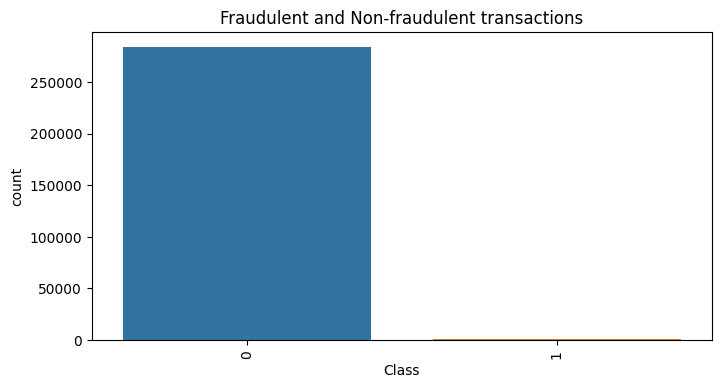

In [ ]:
# Create a bar plot for the number and percentage of fraudulent vs non-fraudulent transcations
fig  =  plt.figure(figsize = (8,4))
sns.countplot(x='Class', data=df, order=df['Class'].value_counts().iloc[:15].index)
plt.xticks(rotation = 90)
plt.title('Fraudulent and Non-fraudulent transactions')
plt.show()

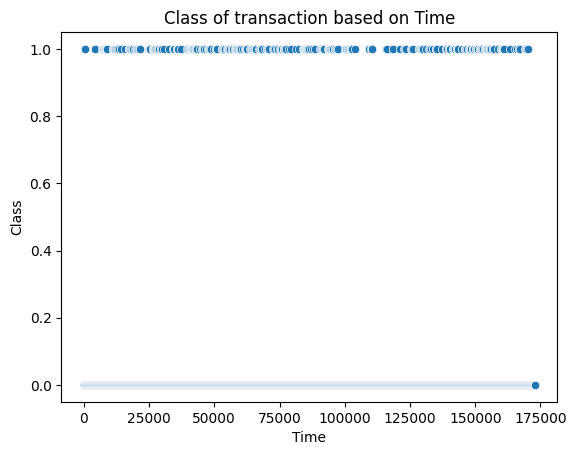

In [ ]:
# Create a scatter plot to observe the distribution of classes with time
sns.scatterplot(x=df['Time'], y=df['Class'])
plt.title("Class of transaction based on Time")
plt.show()

In [ ]:
Split_time = pd.to_timedelta(df['Time'], unit='s')
#Create derived columns Mins and hours
df['Day'] = (Split_time.dt.components.days).astype(int)
df['Hour'] = (Split_time.dt.components.hours).astype(int)
df['Min'] = (Split_time.dt.components.minutes).astype(int)

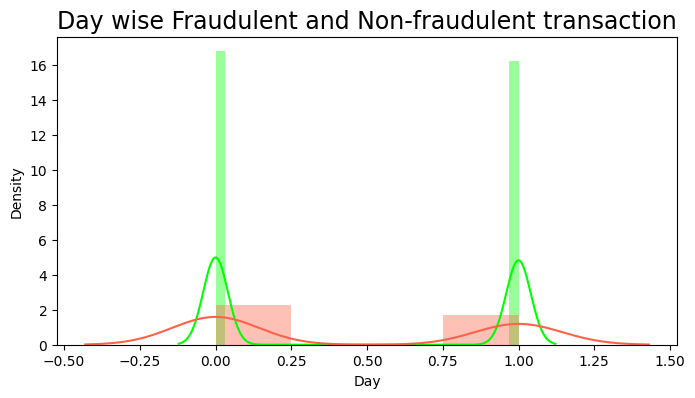

In [ ]:
plt.figure(figsize=(8,4))
sns.distplot(df[df['Class'] == 0]["Day"], color='lime')
sns.distplot(df[df['Class'] == 1]["Day"], color='tomato')
plt.title('Day wise Fraudulent and Non-fraudulent transaction', fontsize=17)
plt.show()

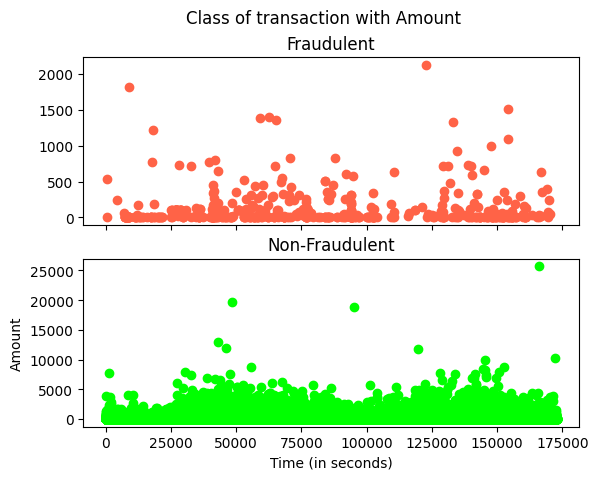

In [ ]:
# Create a scatter plot to observe the distribution of classes with time and amount
fraud = df[df.Class == 1]
nonfraud = df[df.Class == 0]
# time vs Amount

f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Class of transaction with Amount')
ax1.scatter(fraud.Time, fraud.Amount, color = 'tomato')
ax1.set_title('Fraudulent')

ax2.scatter(nonfraud.Time, nonfraud.Amount, color = 'lime')
ax2.set_title('Non-Fraudulent')

plt.xlabel('Time (in seconds)')
plt.ylabel('Amount')
plt.show()


__Observation__

> Density of Fraudulent and Non-fraudulent transaction when observed through scatter plot shows that, 
  - Fraudulent transaction occur rarely.
  - Fraudulent transaction amount is less.



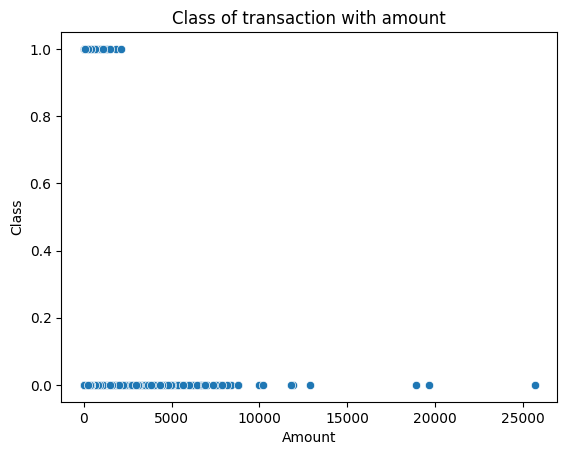

In [ ]:
# Create a scatter plot to observe the distribution of classes with Amount
sns.scatterplot(x=df["Amount"], y=df["Class"])
plt.title("Class of transaction with amount")
plt.show()

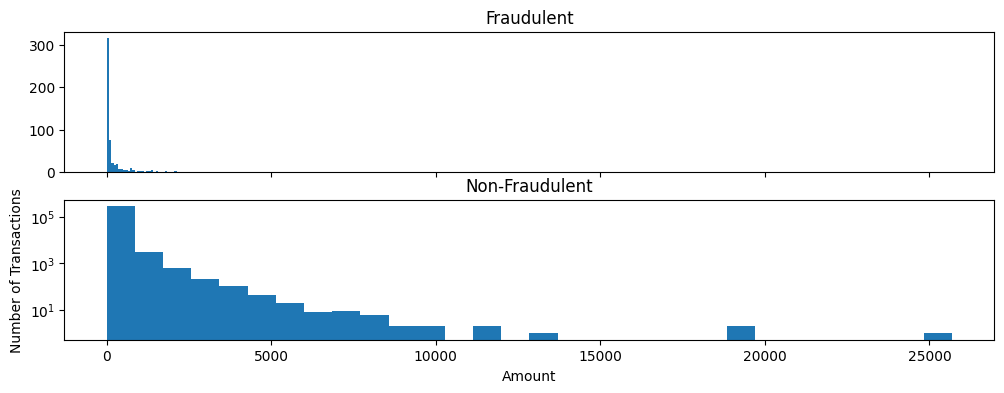

In [ ]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12,4))

bins = 30

ax1.hist(df.Amount[df.Class == 1], bins = bins)
ax1.set_title('Fraudulent')

ax2.hist(df.Amount[df.Class == 0], bins = bins)
ax2.set_title('Non-Fraudulent')

plt.xlabel('Amount')
plt.ylabel('Number of Transactions')
plt.yscale('log')
plt.show()

__Observation__

> Non-Fraudulent transactions are done to high amount, but Fraudulent transactions occurs for less amount.





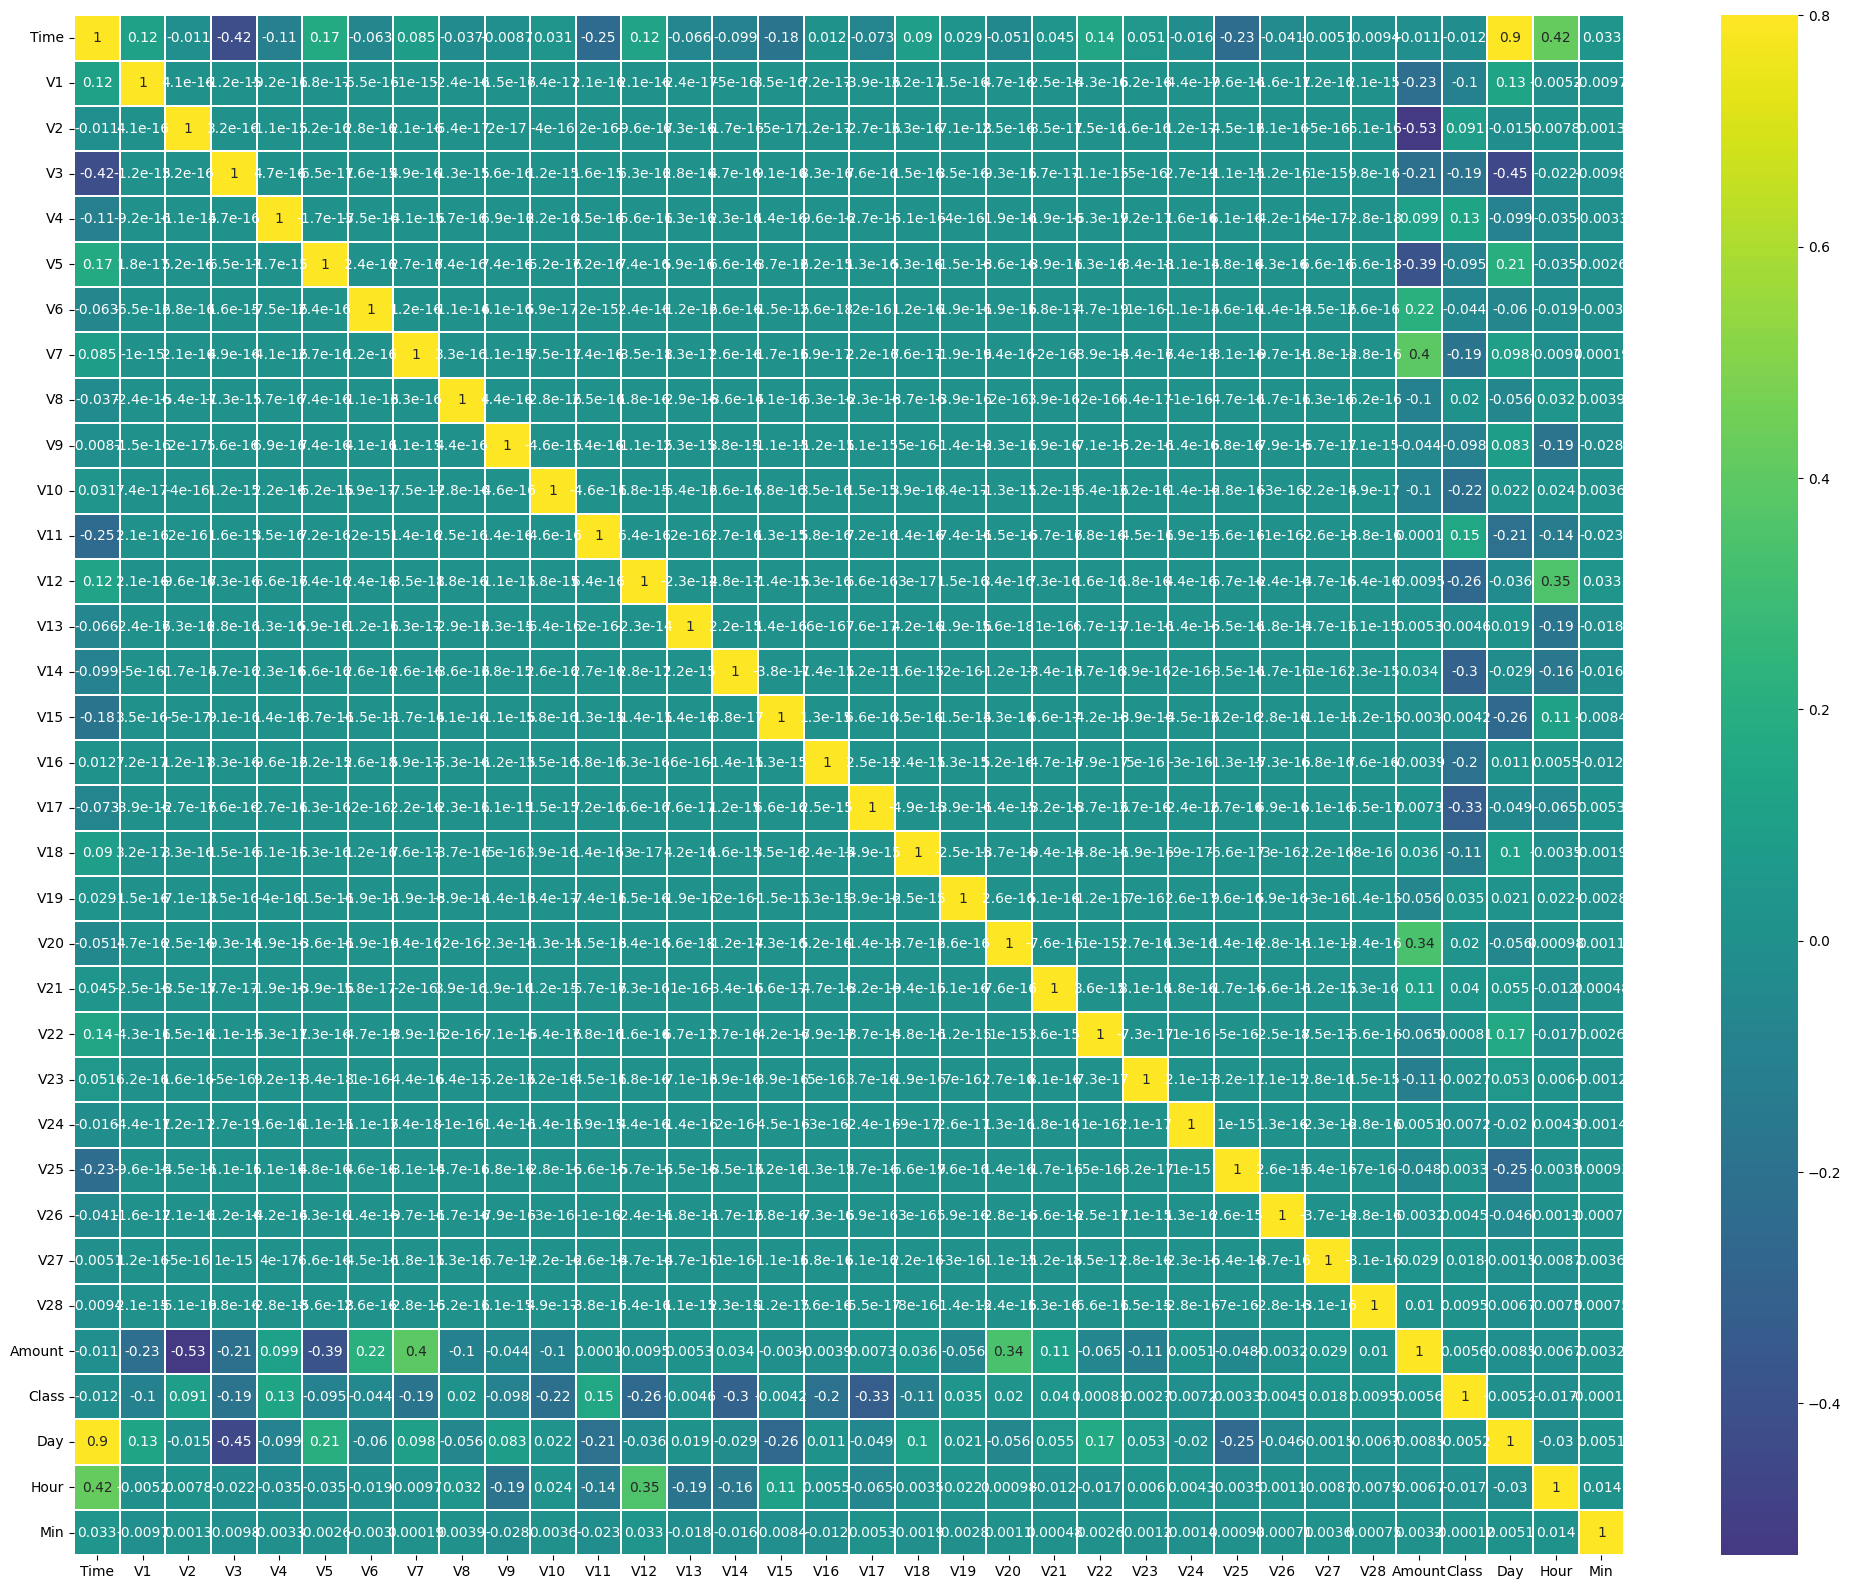

In [ ]:
# Drop unnecessary columns by checking correlation between features
plt.subplots(figsize = (25,20))
sns.heatmap(df.corr(),vmax=.8,linewidth=.01,cmap='viridis' , annot=True, center = 0)
plt.show()

In [ ]:
# Drop unnecessary columns
# We have derived Hour of transacion from Time, so dropping Time, Day and Min
df.drop(['Time','Day','Min'], axis = 1, inplace= True)

## 4. Splitting the data into train & test data

In [ ]:
# Splitting dataset in X and y
y = df['Class']
X = df.drop(['Class'], axis=1)

In [ ]:
# Splitting data in 80(train) 20(test)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size =0.2,stratify = y,random_state = 42)

##### Preserve X_test & y_test to evaluate on the test data once you build the model

In [ ]:
print(np.sum(y))
print(np.sum(y_train))
print(np.sum(y_test))

492
394
98


### Plotting the distribution of a variable

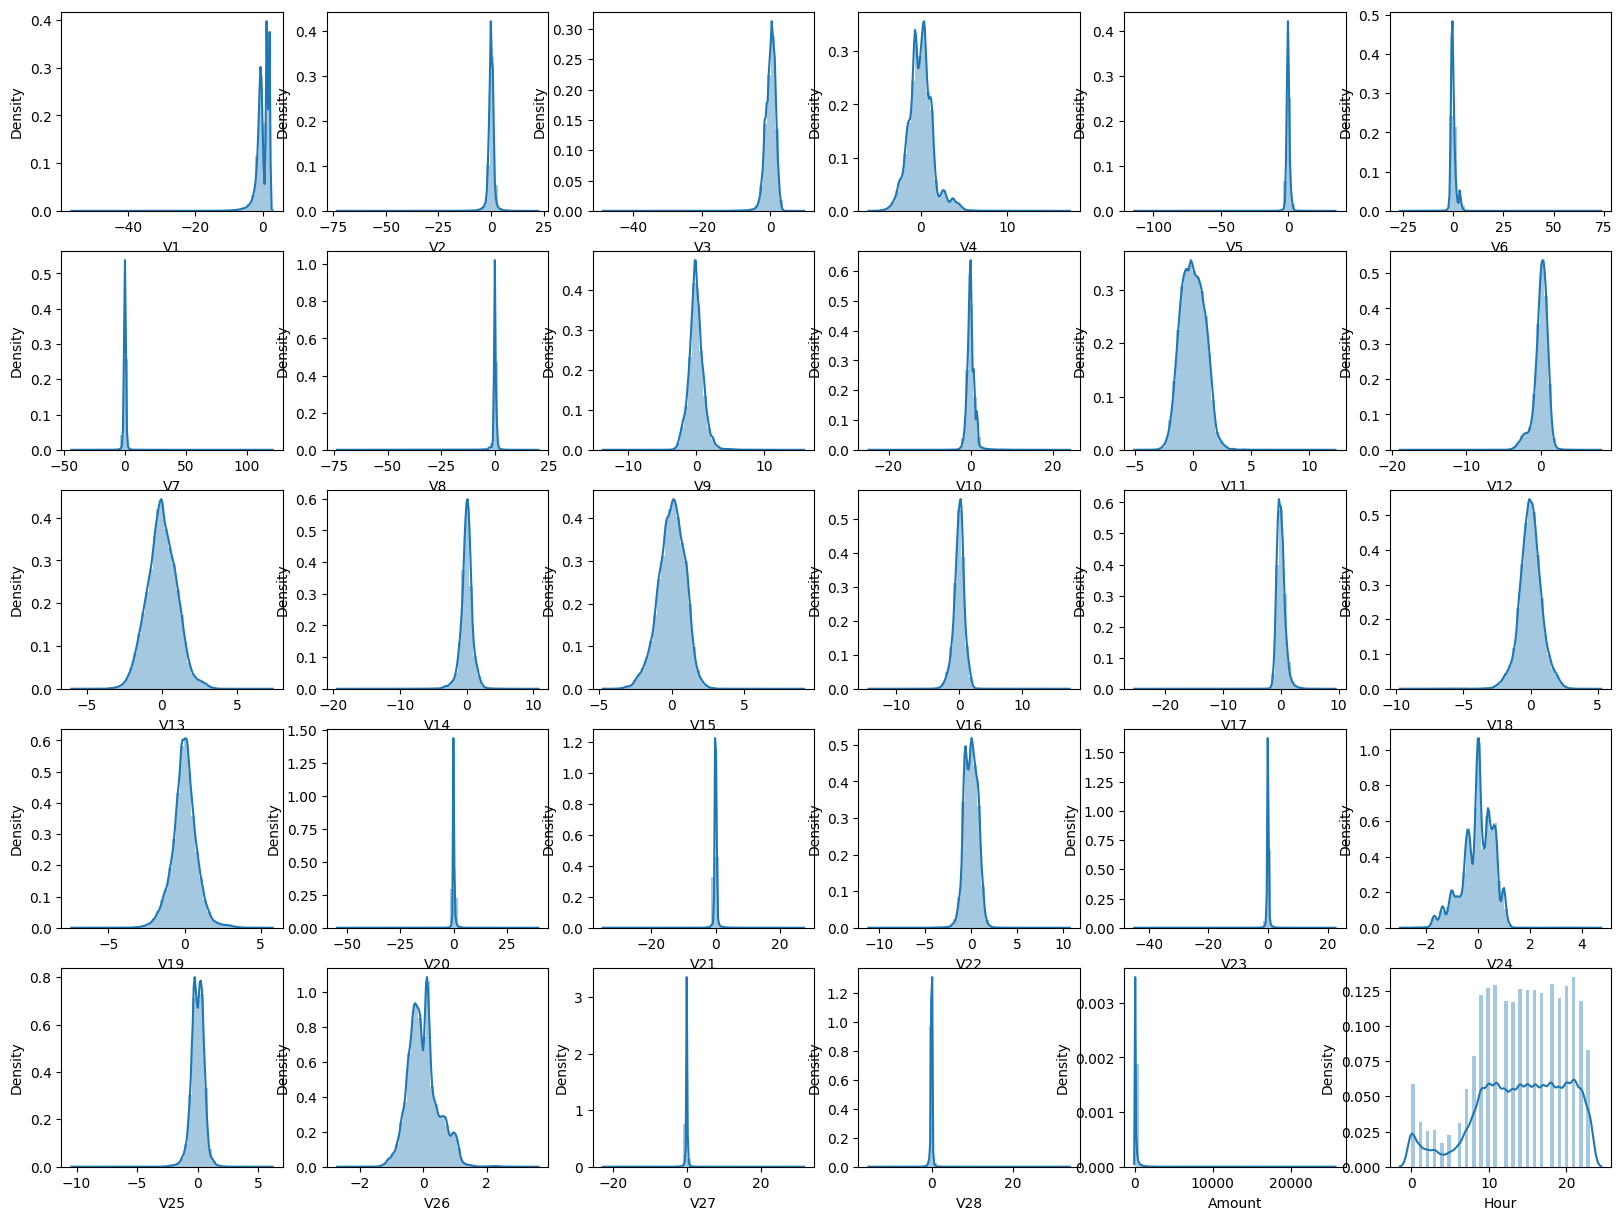

In [ ]:
# plot the histogram of a variable from the dataset to see the skewness
var = X_train.columns

plt.figure(figsize=(20,15))
i=0
for col in var:
    i += 1
    plt.subplot(5,6, i)
    sns.distplot(X_train[col])

plt.show()

__Observation__

- There are skewness observed in some features.
- In order to make our features gaussian, we need to perform Power Transformation.

## 5. Feature Scaling
  - Scaling the feature __Amount__ as all the other features are PCA transformed features.

In [ ]:
scaler = StandardScaler()
# Scaling the train data
X_train[["Amount"]] = scaler.fit_transform(X_train[["Amount"]])
# Transforming the test data
X_test[["Amount"]] = scaler.transform(X_test[["Amount"]])

### If there is skewness present in the distribution use:
- <b>Power Transformer</b> package present in the <b>preprocessing library provided by sklearn</b> to make distribution more gaussian

In [ ]:
# Lets check the skewness of the features
features = X_train.columns
skew_feat = []
for i in features:
    skew_feat.append(X_train[i].skew())

skew_df = pd.concat([pd.DataFrame(features, columns=["Credit card Features"]), pd.DataFrame(skew_feat, columns=["Skew_value"])], axis=1)
skew_df.set_index("Credit card Features", inplace=True)
skew_df.T

Credit card Features,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Hour
Skew_value,-3.306334,-4.779484,-2.247962,0.687574,-2.786851,1.937381,3.152665,-8.639485,0.541869,1.132688,...,3.490183,-0.219171,-6.258558,-0.549854,-0.436292,0.57498,-0.890209,9.978409,18.193943,-0.490314


Extracting features having skewness exceeding +1 and going beyond -1 using skew().

In [ ]:
# Extracting features with high skewness
high_skewess = skew_df.loc[(skew_df["Skew_value"] > 1) | (skew_df["Skew_value"] <-1 )].index
print(high_skewess)

Index(['V1', 'V2', 'V3', 'V5', 'V6', 'V7', 'V8', 'V10', 'V12', 'V14', 'V16',
       'V17', 'V20', 'V21', 'V23', 'V28', 'Amount'],
      dtype='object', name='Credit card Features')


In [ ]:
# Preprocessing.PowerTransformer(copy=False) to fit & transform the train & test data
trans_df = PowerTransformer(copy=False)

# Fitting the power transformer on train data
X_train[high_skewess] = trans_df.fit_transform(X_train[high_skewess])
# Transforming on test data
X_test[high_skewess] = trans_df.transform(X_test[high_skewess])

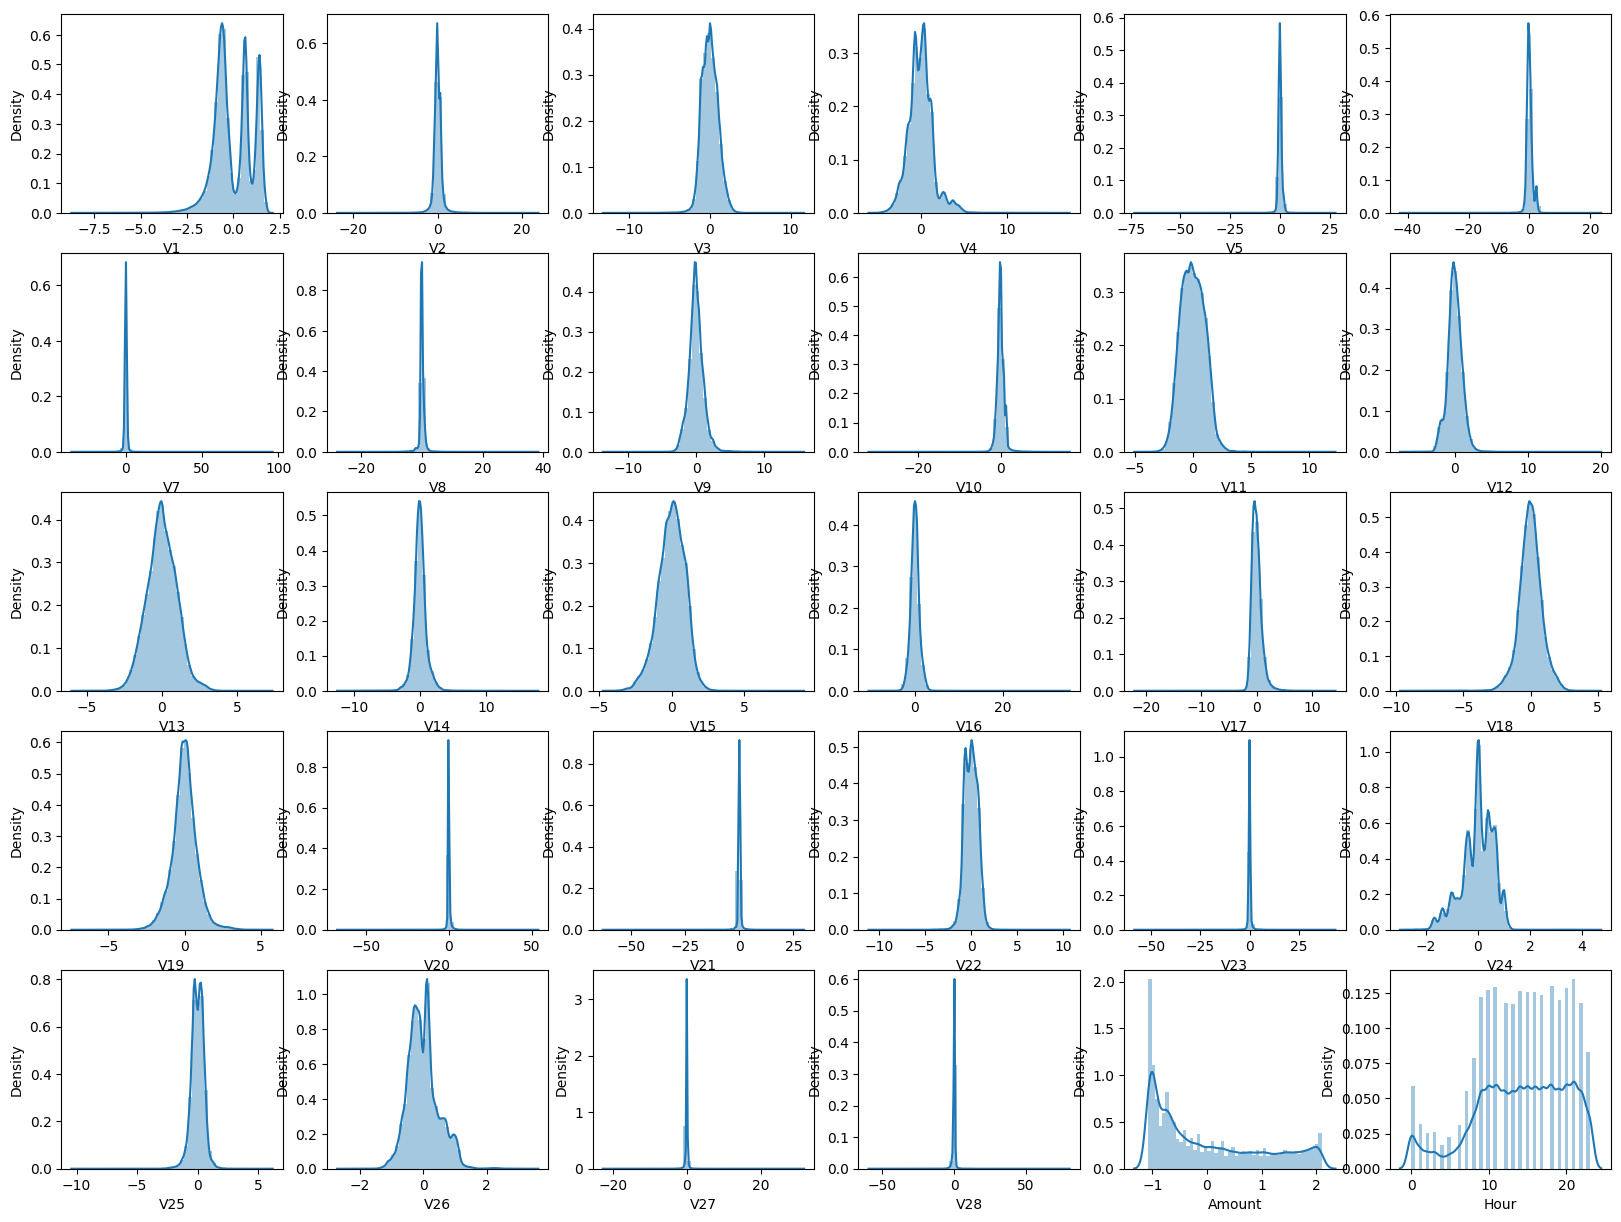

In [ ]:
# plot the histogram of a variable from the dataset again to see the result
var = X_train.columns

plt.figure(figsize=(20,15))
i=0
for col in var:
    i += 1
    plt.subplot(5,6, i)
    sns.distplot(X_train[col])

plt.show()

__Observation__

- Now, the dataset features are more gaussian

## 6. Model Building on Imbalanced Dataset
- Build different models on the imbalanced dataset and see the result

### __1. Logistic Regression on Imbalanced Data__


In [ ]:
# Logistic Regression parameters for K-fold cross validation
params = {"C": [0.01, 0.1, 1, 10, 100, 1000]}
nfolds = StratifiedKFold(n_splits=5, shuffle=True, random_state=4)


#Cross validation
logistic_cv = GridSearchCV(estimator = LogisticRegression(),
                        param_grid = params, 
                        scoring= 'roc_auc', 
                        cv = nfolds, 
                        n_jobs=-1,
                        verbose = 1,
                        return_train_score=True) 
#Hyperparameter tuning
logistic_cv.fit(X_train, y_train)
#print the evaluation result by choosing a evaluation metric
print('Best ROC AUC score: ', logistic_cv.best_score_)
#print the optimum value of hyperparameters
print('Best hyperparameters: ', logistic_cv.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best ROC AUC score:  0.9833421668588276
Best hyperparameters:  {'C': 0.01}


In [ ]:
# cross validation results
logistic_cv_out = pd.DataFrame(logistic_cv.cv_results_)
logistic_cv_out

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,1.904750,0.288155,0.033218,0.003872,0.01,{'C': 0.01},0.986433,0.981760,0.979371,0.986295,...,0.983342,0.002713,1,0.984285,0.984988,0.987537,0.985573,0.985915,0.985660,0.001090
1,3.062235,0.414949,0.040642,0.010384,0.1,{'C': 0.1},0.986712,0.981219,0.975494,0.984268,...,0.981633,0.003793,2,0.982051,0.983654,0.986355,0.983886,0.984415,0.984072,0.001387
2,3.458680,0.412375,0.029260,0.003213,1,{'C': 1},0.986730,0.980408,0.973305,0.983362,...,0.980800,0.004437,3,0.981136,0.982952,0.985850,0.983250,0.983745,0.983386,0.001515
3,3.684306,0.485629,0.038984,0.013994,10,{'C': 10},0.986732,0.980255,0.972984,0.983230,...,0.980675,0.004534,4,0.981026,0.982860,0.985781,0.983170,0.983654,0.983298,0.001527
4,3.476894,0.470482,0.036572,0.010489,100,{'C': 100},0.986733,0.980239,0.972947,0.983222,...,0.980662,0.004547,5,0.981014,0.982852,0.985771,0.983165,0.983645,0.983289,0.001528
5,3.047507,0.530049,0.028219,0.003875,1000,{'C': 1000},0.986727,0.980237,0.972955,0.983219,...,0.980662,0.004542,6,0.981012,0.982851,0.985770,0.983162,0.983644,0.983288,0.001528


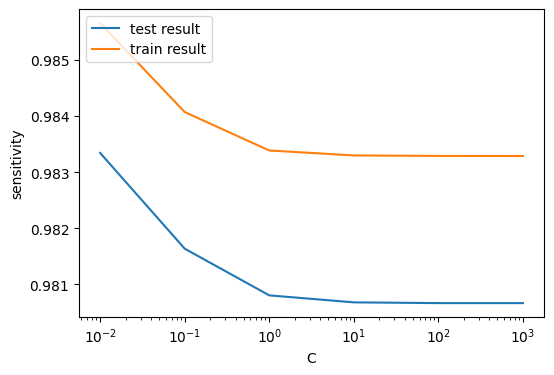

In [ ]:
# plot of C versus train and validation scores
plt.figure(figsize=(6, 4))
plt.plot(logistic_cv_out['param_C'], logistic_cv_out['mean_test_score'])
plt.plot(logistic_cv_out['param_C'], logistic_cv_out['mean_train_score'])
plt.xlabel('C')
plt.ylabel('sensitivity')
plt.legend(['test result', 'train result'], loc='upper left')
plt.xscale('log')

### Logistic Regression with Optimal C

In [ ]:
# Instantiating the model with best C
logr_imbalance = LogisticRegression(C=0.01)

# Fitting the model on train dataset
logr_imbalance.fit(X_train, y_train)

LogisticRegression(C=0.01)

### Prediction and Model Evaluation on train set

In [ ]:
# Creating function to display ROC-AUC score, f1 score and classification report
def display_scores(y_test, y_pred):
    '''
    Display ROC-AUC score, f1 score and classification report of a model.
    '''
    print(f"F1 Score: {round(f1_score(y_test, y_pred)*100,2)}%") 
    print(f"Classification Report: \n {classification_report(y_test, y_pred)}")

In [ ]:
# Predictions on the train set
y_train_pred = logr_imbalance.predict(X_train)

In [ ]:
display_scores(y_train, y_train_pred)

F1 Score: 74.29%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       0.91      0.63      0.74       394

    accuracy                           1.00    227845
   macro avg       0.96      0.81      0.87    227845
weighted avg       1.00      1.00      1.00    227845



In [ ]:
# ROC Curve function
def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()
    return None

In [ ]:
# Predicted probability
y_train_pred_proba = logr_imbalance.predict_proba(X_train)[:,1]

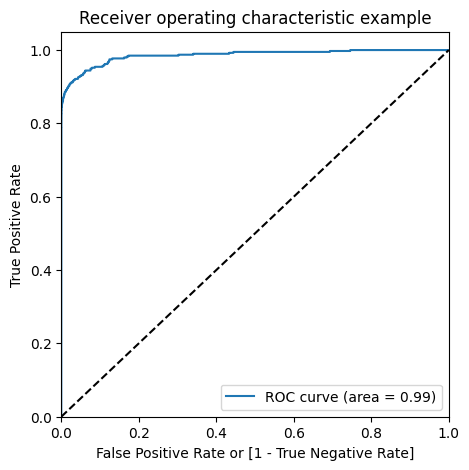

In [ ]:
# Plot the ROC curve
draw_roc(y_train, y_train_pred_proba)

### Evaluating the model on test set

In [ ]:
# Making prediction on the test set
y_test_pred = logr_imbalance.predict(X_test)
display_scores(y_test, y_test_pred)

F1 Score: 72.83%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.64      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# Predicted probability
y_test_pred_proba = logr_imbalance.predict_proba(X_test)[:,1]

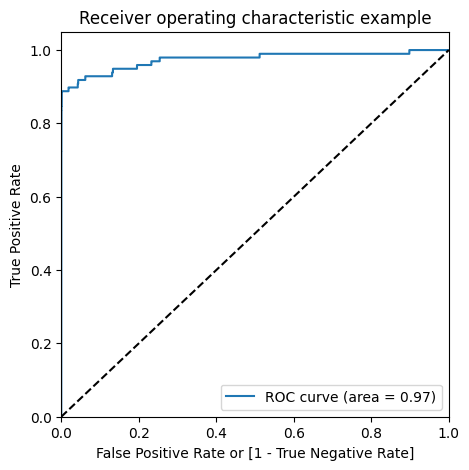

In [ ]:
# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba)

__Observation from Logistic Regression on Imbalanced Dataset__
  - F1 score on Train set 74.29%
  - ROC score on train dataset is 98%

  - F1 score on test set 72.83%
  - A good ROC curve of 97% is obtained from test data.
  

### __2. Decision Tree on Imbalanced Dataset__

In [ ]:
# Create the parameter grid 
param_grid = {
    'max_depth': range(5, 15, 5),
    'min_samples_leaf': range(50, 150, 50),
    'min_samples_split': range(50, 150, 50),
}


# Instantiate the grid search model
dtree = DecisionTreeClassifier()

grid_search = GridSearchCV(estimator = dtree, 
                           param_grid = param_grid, 
                           scoring= 'roc_auc',
                           cv = 3, 
                           n_jobs=-1,
                           verbose = 1)

# Fit the grid search to the data
grid_search.fit(X_train,y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'max_depth': range(5, 15, 5),
                         'min_samples_leaf': range(50, 150, 50),
                         'min_samples_split': range(50, 150, 50)},
             scoring='roc_auc', verbose=1)

In [ ]:
# cv results
dt_cv = pd.DataFrame(grid_search.cv_results_)
dt_cv

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,6.906116,0.766138,0.043621,0.006580,5,50,50,"{'max_depth': 5, 'min_samples_leaf': 50, 'min_...",0.901305,0.934344,0.936856,0.924168,0.016199,6
1,6.810817,0.744485,0.040954,0.000581,5,50,100,"{'max_depth': 5, 'min_samples_leaf': 50, 'min_...",0.901305,0.934344,0.936854,0.924168,0.016199,7
2,6.368370,0.731405,0.047570,0.002439,5,100,50,"{'max_depth': 5, 'min_samples_leaf': 100, 'min...",0.928512,0.934740,0.944521,0.935924,0.006589,1
3,6.338710,0.681452,0.039928,0.002998,5,100,100,"{'max_depth': 5, 'min_samples_leaf': 100, 'min...",0.928512,0.934740,0.944521,0.935924,0.006589,1
4,12.973849,0.044822,0.043800,0.000684,10,50,50,"{'max_depth': 10, 'min_samples_leaf': 50, 'min...",0.902159,0.939762,0.920469,0.920797,0.015353,8
5,13.064973,0.082694,0.043087,0.001962,10,50,100,"{'max_depth': 10, 'min_samples_leaf': 50, 'min...",0.909596,0.939749,0.927939,0.925761,0.012406,5
6,12.989602,0.130210,0.046322,0.002168,10,100,50,"{'max_depth': 10, 'min_samples_leaf': 100, 'mi...",0.899740,0.940993,0.949320,0.930017,0.021678,3
7,12.954966,0.091324,0.041310,0.008446,10,100,100,"{'max_depth': 10, 'min_samples_leaf': 100, 'mi...",0.907100,0.933469,0.941844,0.927471,0.014805,4


In [ ]:
# Printing the optimal score and hyperparameters
print("Best roc auc score : ", grid_search.best_score_)
print(grid_search.best_estimator_)

Best roc auc score :  0.9359244925074665
DecisionTreeClassifier(max_depth=5, min_samples_leaf=100, min_samples_split=50)


### Decision tree with optimal hyperparameters

In [ ]:
# Model with optimal hyperparameters
dt_imbalance = DecisionTreeClassifier(criterion = "gini", random_state = 100,max_depth=10, min_samples_leaf=100,min_samples_split=100)
dt_imbalance.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=100,
                       min_samples_split=100, random_state=100)

### Prediction on train set

In [ ]:
y_train_pred = dt_imbalance.predict(X_train)
display_scores(y_train, y_train_pred)

F1 Score: 68.32%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       0.88      0.56      0.68       394

    accuracy                           1.00    227845
   macro avg       0.94      0.78      0.84    227845
weighted avg       1.00      1.00      1.00    227845



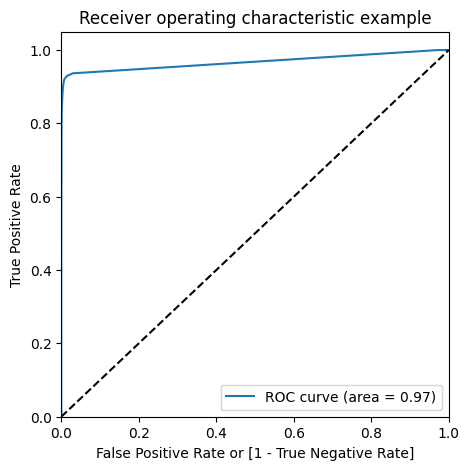

In [ ]:
# Predicted probability
y_train_pred_proba = dt_imbalance.predict_proba(X_train)[:,1]

# Plot the ROC curve
draw_roc(y_train, y_train_pred_proba)

### Evaluating the model on test set

In [ ]:
y_test_pred = dt_imbalance.predict(X_test)
display_scores(y_test, y_test_pred)

F1 Score: 61.73%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.51      0.62        98

    accuracy                           1.00     56962
   macro avg       0.89      0.75      0.81     56962
weighted avg       1.00      1.00      1.00     56962



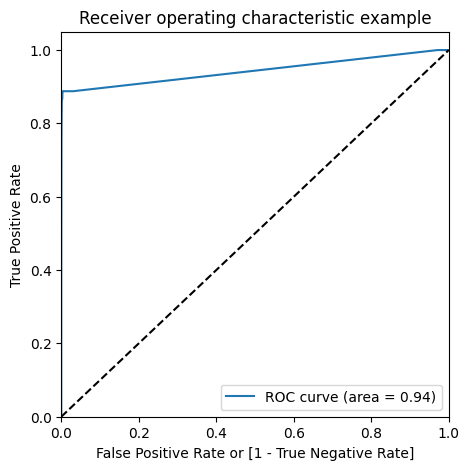

In [ ]:
# Predicted probability
y_test_pred_proba = dt_imbalance.predict_proba(X_test)[:,1]
# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba)

__Observation from Decision Tree o unbalanced data__
  - F1 Score on train data is 68%
  - ROC curve obtained on train data 97%
  
  - F1 score on test data is 62%
  - ROC Curve obtained on test data 94%

### __3. XG Boost on Imbalanced Data__

In [ ]:
# creating a KFold object 
folds = 3

# specify range of hyperparameters
xgb_param_grid = {'learning_rate': [0.2, 0.6], 'subsample': [0.3, 0.6, 0.9]}          

# specify model
xgb_model = XGBClassifier(max_depth=2, n_estimators=200)

# set up GridSearchCV()
xgb_cv = GridSearchCV(estimator = xgb_model, 
                        param_grid = xgb_param_grid, 
                        scoring= 'roc_auc', 
                        cv = folds, 
                        verbose = 1,
                        return_train_score=True)      

# fit the model
xgb_cv.fit(X_train, y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=2,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=200, n_jobs=None,
                                     num_parallel_tree=None, predictor=None,
                                     random_state=None, ...),
             param_grid={'learning_rate': [0.2, 0.6],
                         'subsample': [0.3, 0.6, 0.9]},
             return_train_score=True, scoring='roc_auc', verbose=1)

In [ ]:
# cv results
xgb_cv_out = pd.DataFrame(xgb_cv.cv_results_)
xgb_cv_out

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,37.493240,0.866407,0.136225,0.002402,0.2,0.3,"{'learning_rate': 0.2, 'subsample': 0.3}",0.981603,0.973956,0.991454,0.982338,0.007162,2,0.999861,0.999863,0.999170,0.999631,0.000326
1,54.998685,0.883746,0.165491,0.034108,0.2,0.6,"{'learning_rate': 0.2, 'subsample': 0.6}",0.978728,0.978453,0.989688,0.982290,0.005233,3,0.999962,0.999952,0.999863,0.999926,0.000044
2,65.956579,0.692184,0.139604,0.004265,0.2,0.9,"{'learning_rate': 0.2, 'subsample': 0.9}",0.975355,0.982134,0.991185,0.982892,0.006485,1,0.999968,0.999869,0.999868,0.999902,0.000047
3,36.518834,0.616846,0.139788,0.001485,0.6,0.3,"{'learning_rate': 0.6, 'subsample': 0.3}",0.975409,0.958643,0.966665,0.966906,0.006847,6,0.999997,0.999998,0.999959,0.999985,0.000018
4,52.722954,0.435861,0.142267,0.005285,0.6,0.6,"{'learning_rate': 0.6, 'subsample': 0.6}",0.974525,0.967043,0.975055,0.972208,0.003658,5,1.000000,1.000000,1.000000,1.000000,0.000000
5,63.818821,0.505724,0.138813,0.002879,0.6,0.9,"{'learning_rate': 0.6, 'subsample': 0.9}",0.970946,0.967857,0.981935,0.973579,0.006042,4,1.000000,1.000000,1.000000,1.000000,0.000000


In [ ]:
# Printing the optimal score and hyperparameters
print("Best roc auc score : ", xgb_cv.best_score_)
print(xgb_cv.best_estimator_)

Best roc auc score :  0.98289150883177
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=200, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)


In [ ]:
# Printing best params
xgb_cv.best_params_

{'learning_rate': 0.2, 'subsample': 0.9}

### XG Boost model with Optimal Hyperparmeter

In [ ]:
# Printing best params
params = {'learning_rate': 0.2,
          'max_depth': 2, 
          'n_estimators':200,
          'subsample':0.9,
          'objective':'binary:logistic'}

# fit model on training data
xgb_imbalance = XGBClassifier(params = params)
xgb_imbalance.fit(X_train, y_train)

[03:56:56] WARNING: ../src/learner.cc:767: 
Parameters: { "params" } are not used.



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              params={'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 200,
                      'objective': 'binary:logistic', 'subsample': 0.9},
              predictor=None, ...)

### XG Boost model evaluation on train set

In [ ]:
# Predictions on the train set
y_train_pred = xgb_imbalance.predict(X_train)

display_scores(y_train, y_train_pred)

F1 Score: 100.0%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



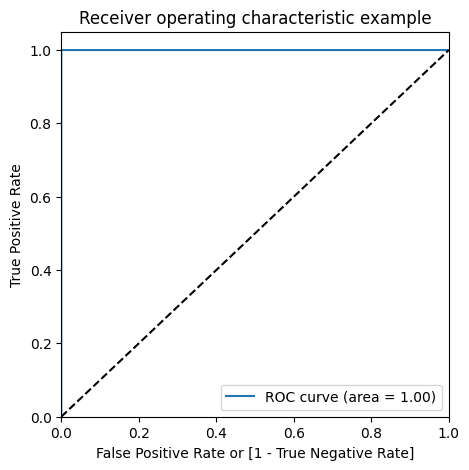

In [ ]:
# Predicted probability
y_train_pred_proba_imbalance = xgb_imbalance.predict_proba(X_train)[:,1]

# Plot the ROC curve
draw_roc(y_train, y_train_pred_proba_imbalance)

### Evaluating the model on the test set

In [ ]:
# Predictions on the test set
y_test_pred = xgb_imbalance.predict(X_test)
display_scores(y_test, y_test_pred)

F1 Score: 88.04%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



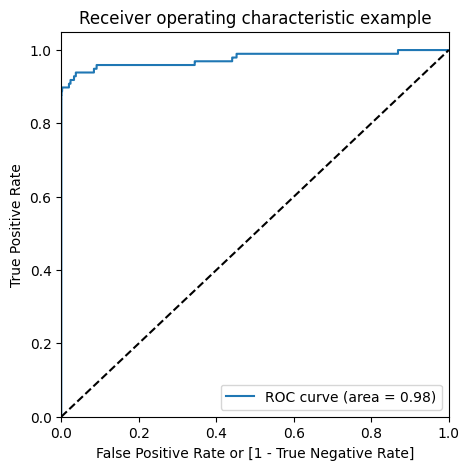

In [ ]:
# Predicted probability
y_test_pred_proba = xgb_imbalance.predict_proba(X_test)[:,1]

# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba)

 __Observation from XG Boost model on imbalanced data__

  - F1 Score on train data is 100%
  - ROC curve on train data is 1
  - F1 score on test data is 88%
  - ROC curve on test data is 98%

### Print the important features of the best model to understand the dataset
- This will not give much explanation on the already transformed dataset
- But it will help us in understanding if the dataset is not PCA transformed

Top var = 17
2nd Top var = 14
3rd Top var = 10


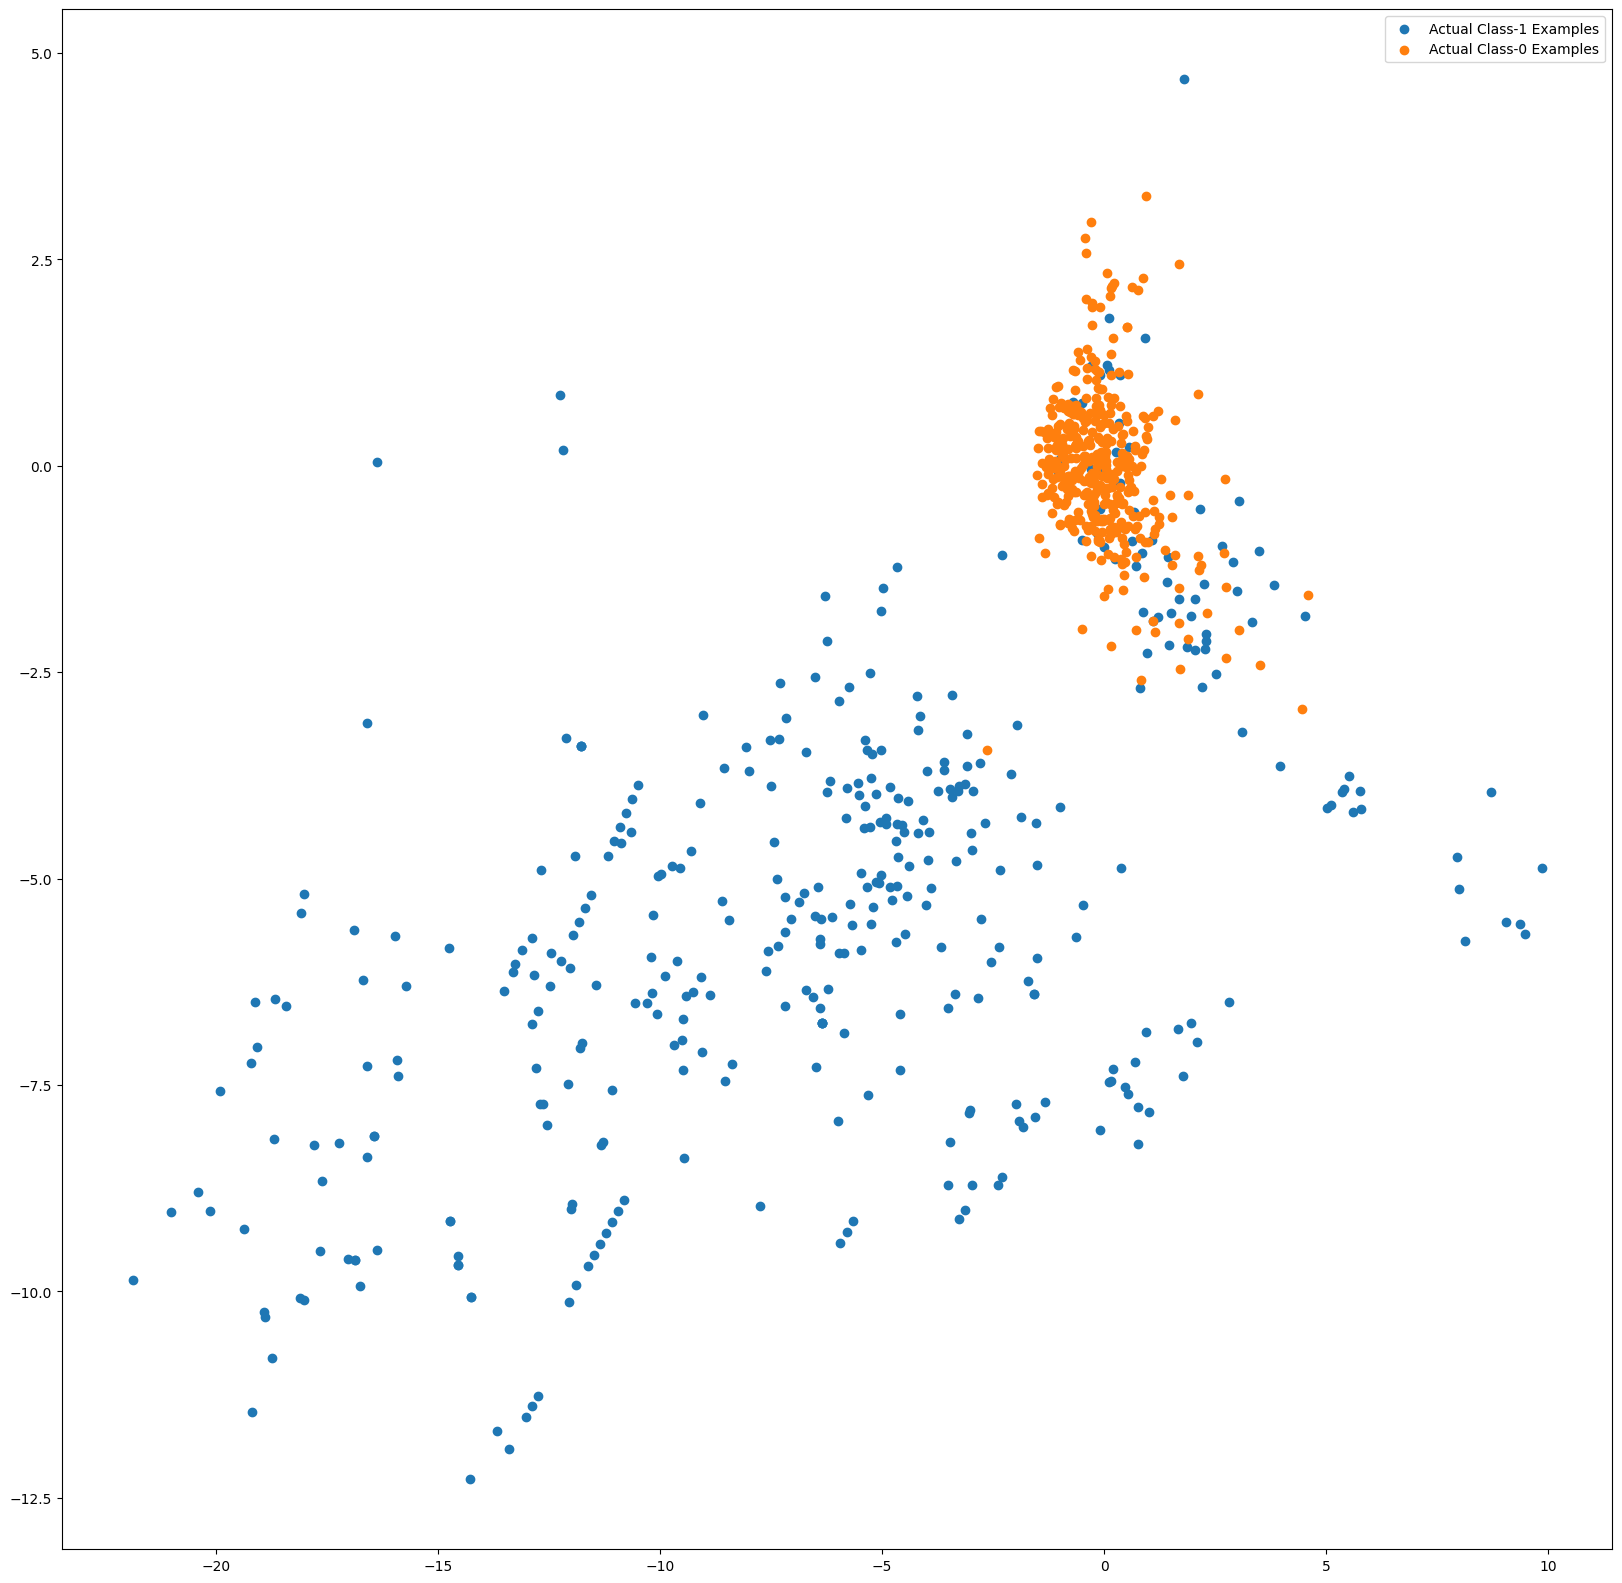

In [ ]:
var_imp = []
for i in xgb_imbalance.feature_importances_:
    var_imp.append(i)
print('Top var =', var_imp.index(np.sort(xgb_imbalance.feature_importances_)[-1])+1)
print('2nd Top var =', var_imp.index(np.sort(xgb_imbalance.feature_importances_)[-2])+1)
print('3rd Top var =', var_imp.index(np.sort(xgb_imbalance.feature_importances_)[-3])+1)

# Variable on Index-16 and Index-13 seems to be the top 2 variables
top_var_index = var_imp.index(np.sort(xgb_imbalance.feature_importances_)[-1])
second_top_var_index = var_imp.index(np.sort(xgb_imbalance.feature_importances_)[-2])

X_train_1 = X_train.to_numpy()[np.where(y_train==1.0)]
X_train_0 = X_train.to_numpy()[np.where(y_train==0.0)]

np.random.shuffle(X_train_0)

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 20]

plt.scatter(X_train_1[:, top_var_index], X_train_1[:, second_top_var_index], label='Actual Class-1 Examples')
plt.scatter(X_train_0[:X_train_1.shape[0], top_var_index], X_train_0[:X_train_1.shape[0], second_top_var_index],
            label='Actual Class-0 Examples')
plt.legend()

## 7.Model building with balancing Classes

##### Perform class balancing with :
- Random Oversampling
- SMOTE
- ADASYN

### __Random Oversampling__

In [ ]:
from imblearn.over_sampling import RandomOverSampler

# define oversampling strategy
oversample = RandomOverSampler(sampling_strategy='minority')
# fit and apply the transform
X_over, y_over = oversample.fit_resample(X_train, y_train)

In [ ]:
# Finding class distribution after applying random oversampling
from collections import Counter
print('Before Random oversampling:-',Counter(y_train))
print('After Random Oversapling:-',Counter(y_over))

Before Random oversampling:- Counter({0: 227451, 1: 394})
After Random Oversapling:- Counter({0: 227451, 1: 227451})


### __1.Logistic Regression after Random Oversampling__

In [ ]:
# Specify params
params = {"C": [0.01, 0.1, 1, 10, 100, 1000]}
# Creating KFold object with 5 splits
nfolds = StratifiedKFold(n_splits=5, shuffle=True, random_state=4)

# Specifing score as roc-auc
ransamp_logistic_cv = GridSearchCV(estimator = LogisticRegression(),
                        param_grid = params, 
                        scoring= 'roc_auc', 
                        cv = folds, 
                        verbose = 1,
                        return_train_score=True) 

# Fit the model
ransamp_logistic_cv.fit(X_over, y_over)
#print the evaluation result by choosing a evaluation metric
print('Best ROC AUC score: ', ransamp_logistic_cv.best_score_)
#print the optimum value of hyperparameters
print('Best hyperparameters: ', ransamp_logistic_cv.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best ROC AUC score:  0.9885336184432599
Best hyperparameters:  {'C': 1000}


In [ ]:
# cross validation results
ransamp_logistic_cv_out = pd.DataFrame(ransamp_logistic_cv.cv_results_)
ransamp_logistic_cv_out

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,4.603294,1.010360,0.092307,0.002784,0.01,{'C': 0.01},0.987995,0.988695,0.988520,0.988403,0.000297,6,0.988561,0.988248,0.988437,0.988415,0.000128
1,5.343779,1.855344,0.124523,0.040151,0.1,{'C': 0.1},0.988109,0.988806,0.988639,0.988518,0.000297,5,0.988678,0.988358,0.988550,0.988529,0.000132
2,4.373841,0.798327,0.131821,0.059505,1,{'C': 1},0.988124,0.988821,0.988653,0.988532,0.000297,4,0.988692,0.988369,0.988563,0.988541,0.000132
3,4.695240,0.635512,0.089594,0.000605,10,{'C': 10},0.988125,0.988822,0.988653,0.988533,0.000297,3,0.988692,0.988370,0.988564,0.988542,0.000132
4,4.242725,1.016204,0.087590,0.001055,100,{'C': 100},0.988124,0.988822,0.988654,0.988533,0.000297,2,0.988692,0.988370,0.988564,0.988542,0.000132
5,4.477179,1.027238,0.125966,0.039421,1000,{'C': 1000},0.988125,0.988822,0.988654,0.988534,0.000297,1,0.988692,0.988370,0.988565,0.988543,0.000132


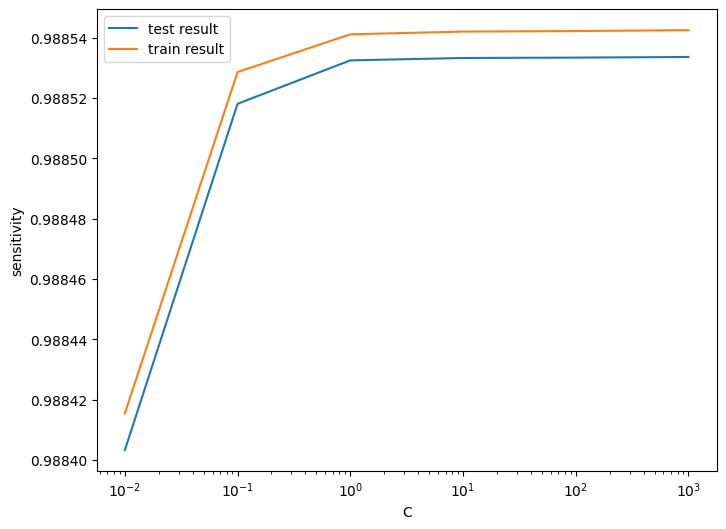

In [ ]:
# plot of C versus train and validation scores

plt.figure(figsize=(8, 6))
plt.plot(ransamp_logistic_cv_out['param_C'], ransamp_logistic_cv_out['mean_test_score'])
plt.plot(ransamp_logistic_cv_out['param_C'], ransamp_logistic_cv_out['mean_train_score'])
plt.xlabel('C')
plt.ylabel('sensitivity')
plt.legend(['test result', 'train result'], loc='upper left')
plt.xscale('log')

### Applying hyperparameter tuning on Logitic Regression

In [ ]:
ransamp_logistic_cv.best_params_

{'C': 1000}

In [ ]:
# Instantiating the model
logreg_over = LogisticRegression(C=1000)

# Fitting the model with train data
logreg_over_model = logreg_over.fit(X_over, y_over)

### Evaluating the model on train data

In [ ]:
# Predictions on the train set
y_train_pred = logreg_over_model.predict(X_over)

In [ ]:
# Printing scores
display_scores(y_over, y_train_pred)

F1 Score: 94.86%
Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.97      0.95    227451
           1       0.97      0.93      0.95    227451

    accuracy                           0.95    454902
   macro avg       0.95      0.95      0.95    454902
weighted avg       0.95      0.95      0.95    454902



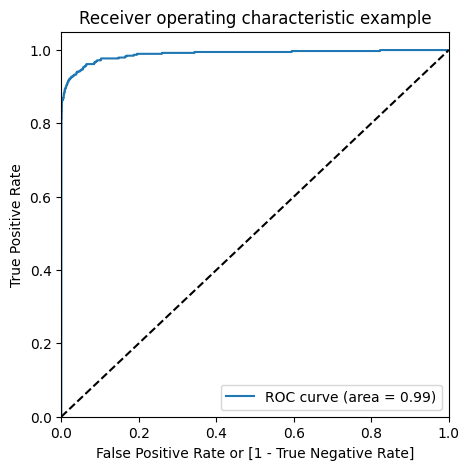

In [ ]:
# Predicted probability
y_train_pred_proba = logreg_over_model.predict_proba(X_over)[:,1]
# Plot the ROC curve
draw_roc(y_over, y_train_pred_proba)

### Evaluating on test data

In [ ]:
# Evaluating on test data
y_test_pred = logreg_over_model.predict(X_test)

# Printing the scores
display_scores(y_test, y_test_pred)

F1 Score: 9.63%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.91      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



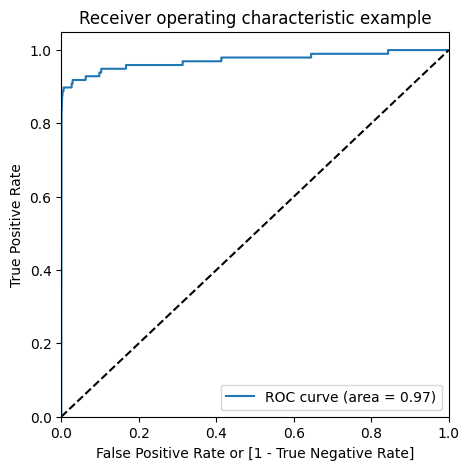

In [ ]:
# Predicted probability
y_test_pred_proba = logreg_over_model.predict_proba(X_test)[:,1]

# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba)

__Observation on Logistic Regression with Decision tree__

- F1 Score on train data 94.86%.
- ROC curve on train data 99%

- F1 score on test data 9.63%
- ROC curve value on tests data 97%

### __2.Decision tree after applying Random Over Sampling__

In [ ]:
# Create the parameter grid 
param_grid = {
    'max_depth': range(5, 15, 5),
    'min_samples_leaf': range(50, 150, 50),
    'min_samples_split': range(50, 150, 50),
}


# Instantiate the grid search model
dtree = DecisionTreeClassifier()

grid_search = GridSearchCV(estimator = dtree, 
                           param_grid = param_grid, 
                           scoring= 'roc_auc',
                           cv = 3, 
                           n_jobs=-1,
                           verbose = 1)

# Fit the grid search to the data
grid_search.fit(X_over,y_over)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'max_depth': range(5, 15, 5),
                         'min_samples_leaf': range(50, 150, 50),
                         'min_samples_split': range(50, 150, 50)},
             scoring='roc_auc', verbose=1)

In [ ]:
# Printing the optimal roc score and hyperparameters
print("Best roc auc score : ", grid_search.best_score_)
print(grid_search.best_estimator_)

Best roc auc score :  0.9994820486224879
DecisionTreeClassifier(max_depth=10, min_samples_leaf=100,
                       min_samples_split=100)


### Decision tree with optimal hyperparameter

In [ ]:
# Model with optimal hyperparameters
dt_over_model = DecisionTreeClassifier(criterion = "gini", 
                                  random_state = 100,
                                  max_depth=10, 
                                  min_samples_leaf=100,
                                  min_samples_split=100)

dt_over_model.fit(X_over, y_over)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=100,
                       min_samples_split=100, random_state=100)

### Model Evaluation on train data

In [ ]:
# Predictions on the train set
y_train_pred = dt_over_model.predict(X_over)
display_scores(y_over, y_train_pred)

F1 Score: 99.58%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    227451
           1       0.99      1.00      1.00    227451

    accuracy                           1.00    454902
   macro avg       1.00      1.00      1.00    454902
weighted avg       1.00      1.00      1.00    454902



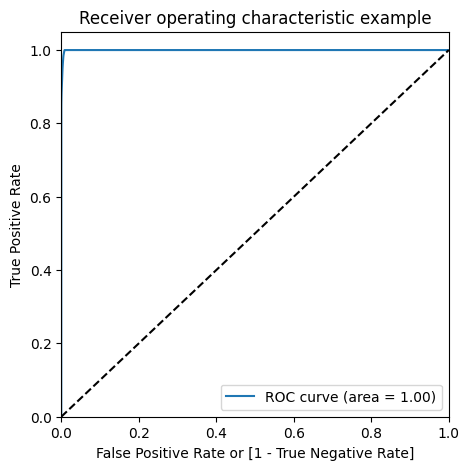

In [ ]:
# Predicted probability
y_train_pred_proba = dt_over_model.predict_proba(X_over)[:,1]
# Plot the ROC curve
draw_roc(y_over, y_train_pred_proba)

### Predictions on test data

In [ ]:
# Evaluating model on the test data
y_test_pred = dt_over_model.predict(X_test)
display_scores(y_test, y_test_pred)

F1 Score: 22.54%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.13      0.82      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.90      0.61     56962
weighted avg       1.00      0.99      0.99     56962



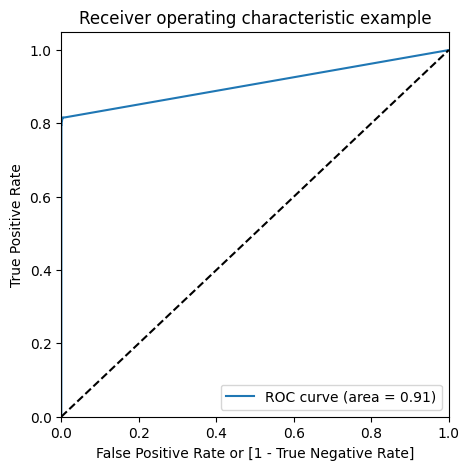

In [ ]:
# Predicted probability
y_test_pred_proba = dt_over_model.predict_proba(X_test)[:,1]
# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba)

__Observations on Decision Tree after Random Oversampling__ 

- F1 score on train data 1
- ROC value on train data 99%

- F1 score value on test data 22.54%
- ROC value on test data 91%


### __3. XG Boost after applying Random Oversampling__

In [ ]:
# creating a KFold object 
folds = 3

# specify range of hyperparameters
param_grid = {'learning_rate': [0.2, 0.6], 
             'subsample': [0.3, 0.6, 0.9]}          


# specify model
xgb_model = XGBClassifier(max_depth=2, n_estimators=200)

# set up GridSearchCV()
xgb_randomsample_cv = GridSearchCV(estimator = xgb_model, 
                        param_grid = param_grid, 
                        scoring= 'roc_auc', 
                        cv = folds, 
                        verbose = 1,
                        return_train_score=True)      

# fit the model
xgb_randomsample_cv.fit(X_over, y_over) 

Fitting 3 folds for each of 6 candidates, totalling 18 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=2,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=200, n_jobs=None,
                                     num_parallel_tree=None, predictor=None,
                                     random_state=None, ...),
             param_grid={'learning_rate': [0.2, 0.6],
                         'subsample': [0.3, 0.6, 0.9]},
             return_train_score=True, scoring='roc_auc', verbose=1)

In [ ]:
# cv results
xgb_randsample_cv_out = pd.DataFrame(xgb_randomsample_cv.cv_results_)
xgb_randsample_cv_out

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,64.769226,1.101323,0.273793,0.006093,0.2,0.3,"{'learning_rate': 0.2, 'subsample': 0.3}",0.999925,0.999859,0.999913,0.999899,0.000029,5,0.999900,0.999924,0.999911,0.999912,1.012447e-05
1,86.182274,0.581877,0.272883,0.004771,0.2,0.6,"{'learning_rate': 0.2, 'subsample': 0.6}",0.999916,0.999870,0.999917,0.999901,0.000022,4,0.999902,0.999931,0.999896,0.999910,1.522550e-05
2,94.931507,0.087881,0.348935,0.113612,0.2,0.9,"{'learning_rate': 0.2, 'subsample': 0.9}",0.999923,0.999849,0.999924,0.999899,0.000035,6,0.999905,0.999922,0.999911,0.999912,7.109375e-06
3,64.023920,0.766377,0.267184,0.002297,0.6,0.3,"{'learning_rate': 0.6, 'subsample': 0.3}",0.999997,0.999969,0.999976,0.999981,0.000012,3,0.999999,1.000000,0.999998,0.999999,8.114362e-07
4,85.779110,0.853115,0.264748,0.001384,0.6,0.6,"{'learning_rate': 0.6, 'subsample': 0.6}",0.999995,0.999971,0.999986,0.999984,0.000010,2,1.000000,0.999999,0.999999,0.999999,3.935082e-07
5,95.091908,1.160674,0.331752,0.078754,0.6,0.9,"{'learning_rate': 0.6, 'subsample': 0.9}",1.000000,0.999975,0.999979,0.999985,0.000011,1,0.999997,0.999997,0.999999,0.999998,8.318346e-07


In [ ]:
# Printing the optimal score and hyperparameters
print("Best roc auc score : ", xgb_randomsample_cv.best_score_)
print(xgb_randomsample_cv.best_estimator_)

Best roc auc score :  0.9999847063603916
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.6, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=200, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)


In [ ]:
xgb_randomsample_cv.best_params_

{'learning_rate': 0.6, 'subsample': 0.9}

### XG Boost with optimal Hyperparameter

In [ ]:
# chosen hyperparameters
params = {'learning_rate': 0.6,
          'max_depth': 2, 
          'n_estimators':200,
          'subsample':0.9,
         'objective':'binary:logistic'}

# fit model on training data
xgb_over_model = XGBClassifier(params = params)
xgb_over_model.fit(X_over, y_over)

[08:34:33] WARNING: ../src/learner.cc:767: 
Parameters: { "params" } are not used.



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              params={'learning_rate': 0.6, 'max_depth': 2, 'n_estimators': 200,
                      'objective': 'binary:logistic', 'subsample': 0.9},
              predictor=None, ...)

### Model Evaluation on Train Data

In [ ]:
# Predictions on the train set
y_train_pred = xgb_over_model.predict(X_over)

display_scores(y_over, y_train_pred)

F1 Score: 100.0%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00    227451

    accuracy                           1.00    454902
   macro avg       1.00      1.00      1.00    454902
weighted avg       1.00      1.00      1.00    454902



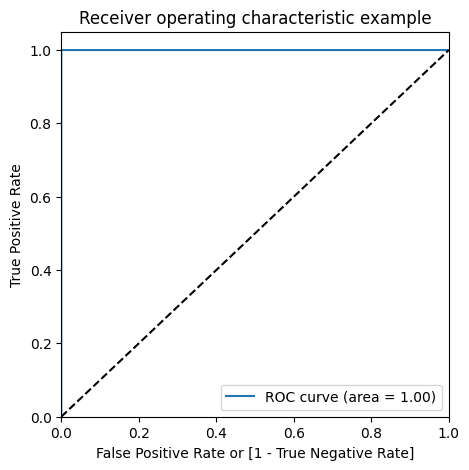

In [ ]:
# Predicted probability
y_train_pred_proba = xgb_over_model.predict_proba(X_over)[:,1]

# Plot the ROC curve
draw_roc(y_over, y_train_pred_proba)

### Model Evaluation on test data

In [ ]:
y_pred = xgb_over_model.predict(X_test)
display_scores(y_test, y_pred)

F1 Score: 85.26%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



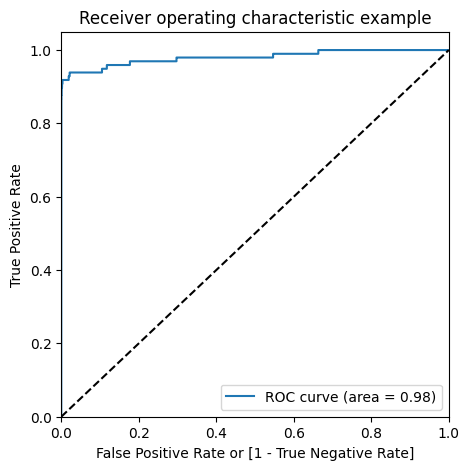

In [ ]:
# Predicted probability
y_test_pred_proba = xgb_over_model.predict_proba(X_test)[:,1]

# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba)

__Observation on XG Boost after Random Oversampling__

- F1 score on trai data 100%
- ROC score on train data 1
- F1 score o test data is 85%
- ROC score on test data is 98%

### __SMOTE__

### Print the class distribution after applying SMOTE 

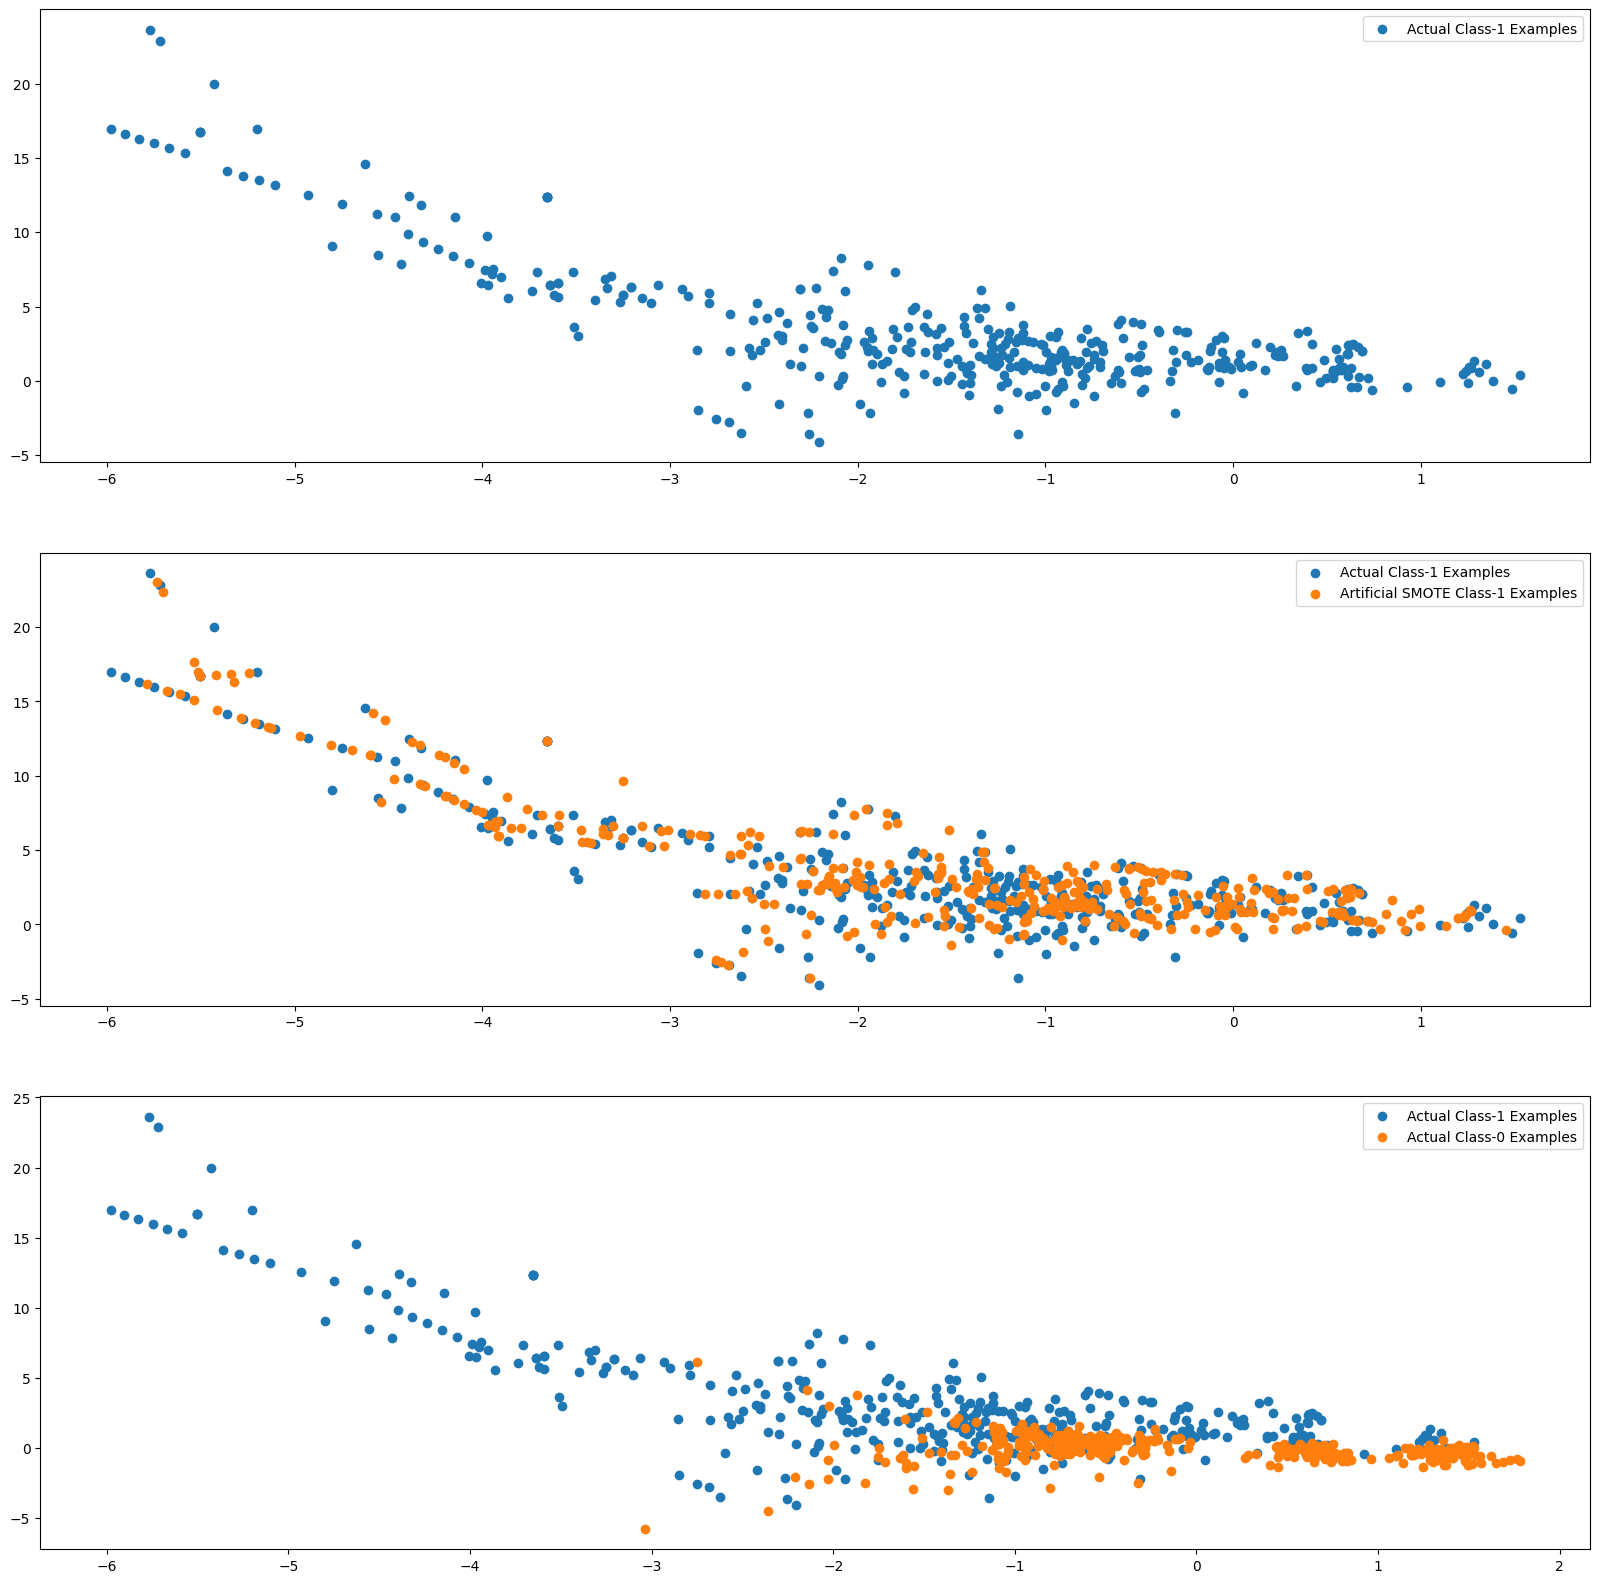

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=0)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)
# Artificial minority samples and corresponding minority labels from SMOTE are appended
# below X_train and y_train respectively
# So to exclusively get the artificial minority samples from SMOTE, we do
X_train_smote_1 = X_train_smote[X_train.shape[0]:]

X_train_1 = X_train.to_numpy()[np.where(y_train==1.0)]
X_train_0 = X_train.to_numpy()[np.where(y_train==0.0)]


plt.rcParams['figure.figsize'] = [20, 20]
fig = plt.figure()

plt.subplot(3, 1, 1)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.legend()

plt.subplot(3, 1, 2)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_train_smote_1.iloc[:X_train_1.shape[0], 0], X_train_smote_1.iloc[:X_train_1.shape[0], 1],
            label='Artificial SMOTE Class-1 Examples')
plt.legend()

plt.subplot(3, 1, 3)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_train_0[:X_train_1.shape[0], 0], X_train_0[:X_train_1.shape[0], 1], label='Actual Class-0 Examples')
plt.legend()

### __1. Logistic Regression after applying SMOTE__

In [ ]:
# Creating KFold object with 5 splits
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=4)

# Specify params
params = {"C": [0.01, 0.1, 1, 10, 100, 1000]}

# Specifing score as roc-auc
logreg_smote_cv = GridSearchCV(estimator = LogisticRegression(),
                        param_grid = params, 
                        scoring= 'roc_auc', 
                        cv = folds, 
                        verbose = 1,
                        return_train_score=True) 

# Fit the model
logreg_smote_cv.fit(X_train_smote, y_train_smote)
#print the evaluation result by choosing a evaluation metric
print('Best ROC AUC score: ', logreg_smote_cv.best_score_)
#print the optimum value of hyperparameters
print('Best hyperparameters: ', logreg_smote_cv.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best ROC AUC score:  0.9901982700881946
Best hyperparameters:  {'C': 10}


In [ ]:
# cross validation results
logreg_smote_cv_out = pd.DataFrame(logreg_smote_cv.cv_results_)
logreg_smote_cv_out

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,5.871211,0.737946,0.050490,0.000696,0.01,{'C': 0.01},0.989764,0.990080,0.989680,0.990540,...,0.990111,0.000357,6,0.990180,0.990115,0.990226,0.990047,0.990057,0.990125,0.000070
1,5.971454,0.868313,0.075047,0.024638,0.1,{'C': 0.1},0.989849,0.990148,0.989750,0.990628,...,0.990189,0.000360,5,0.990262,0.990191,0.990305,0.990123,0.990131,0.990202,0.000071
2,6.031386,0.383342,0.066216,0.021296,1,{'C': 1},0.989857,0.990154,0.989757,0.990640,...,0.990198,0.000362,4,0.990270,0.990199,0.990312,0.990134,0.990140,0.990211,0.000071
3,5.830537,0.691971,0.052231,0.005641,10,{'C': 10},0.989858,0.990154,0.989757,0.990641,...,0.990198,0.000362,1,0.990271,0.990199,0.990313,0.990134,0.990141,0.990212,0.000071
4,6.064305,0.637094,0.057280,0.009042,100,{'C': 100},0.989859,0.990155,0.989755,0.990641,...,0.990198,0.000362,3,0.990271,0.990199,0.990311,0.990135,0.990141,0.990212,0.000070
5,5.903200,0.697528,0.062010,0.021261,1000,{'C': 1000},0.989858,0.990155,0.989755,0.990641,...,0.990198,0.000362,2,0.990271,0.990200,0.990312,0.990134,0.990142,0.990212,0.000070


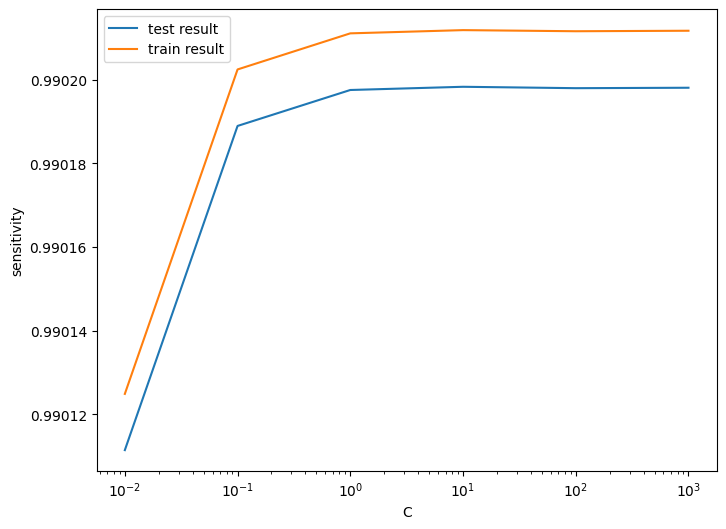

In [ ]:
# plot of C versus train and validation scores

plt.figure(figsize=(8, 6))
plt.plot(logreg_smote_cv_out['param_C'], logreg_smote_cv_out['mean_test_score'])
plt.plot(logreg_smote_cv_out['param_C'], logreg_smote_cv_out['mean_train_score'])
plt.xlabel('C')
plt.ylabel('sensitivity')
plt.legend(['test result', 'train result'], loc='upper left')
plt.xscale('log')

### Logistic Regression with Optimal C

In [ ]:
# Printing best params
logreg_smote_cv.best_params_

{'C': 10}

In [ ]:
# Instantiating the model
logreg_smote_model = LogisticRegression(C=100)

# Fitting the model with balanced data
logreg_smote_model.fit(X_train_smote, y_train_smote)

LogisticRegression(C=100)

### Evaluating the model on Train data

In [ ]:
# Evaluating on train data
y_train_pred = logreg_smote_model.predict(X_train_smote)
display_scores(y_train_smote, y_train_pred)

F1 Score: 94.68%
Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.97      0.95    227451
           1       0.97      0.93      0.95    227451

    accuracy                           0.95    454902
   macro avg       0.95      0.95      0.95    454902
weighted avg       0.95      0.95      0.95    454902



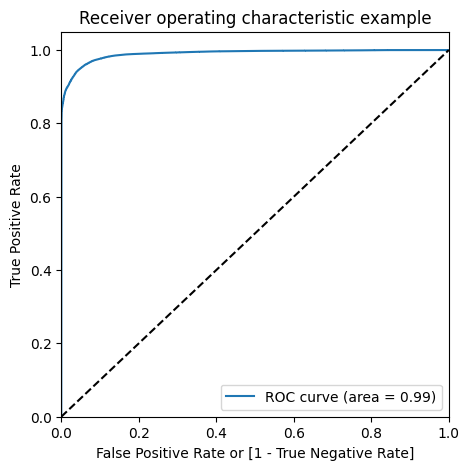

In [ ]:
# Predicted probability
y_train_pred_proba_smote = logreg_smote_model.predict_proba(X_train_smote)[:,1]
# Plot the ROC curve
draw_roc(y_train_smote, y_train_pred_proba_smote)

### Evaluating on test data

In [ ]:
# Evaluating on test data
y_test_pred = logreg_smote_model.predict(X_test)
display_scores(y_test, y_test_pred)

F1 Score: 9.37%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.05      0.92      0.09        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



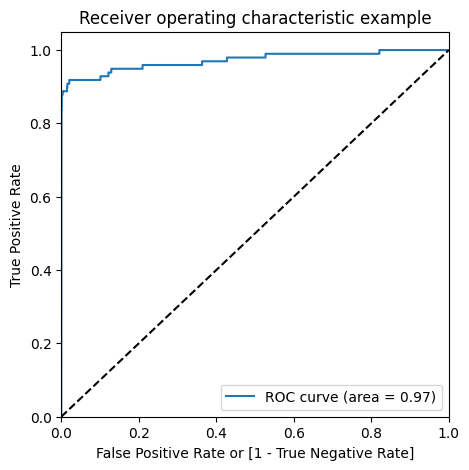

In [ ]:
# Predicted probability
y_test_pred_proba_smote = logreg_smote_model.predict_proba(X_test)[:,1]
# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba_smote)

__Observation on Logistic Regression using SMOTE__
  - F1 score on train data 94.68%
  - ROC score train data 99%
  - F1scoreon test data 9.37%
  - ROC score on test data 97%
  

### __2.Decision tree with SMOTE__

In [ ]:
# Create the parameter grid 
param_grid = {
    'max_depth': range(5, 15, 5),
    'min_samples_leaf': range(50, 150, 50),
    'min_samples_split': range(50, 150, 50),
}


# Instantiate the grid search model
dtree = DecisionTreeClassifier()

grid_search = GridSearchCV(estimator = dtree, 
                           param_grid = param_grid, 
                           scoring= 'roc_auc',
                           cv = 3, 
                           n_jobs=-1,
                           verbose = 1)

# Fit the grid search to the data
grid_search.fit(X_train_smote,y_train_smote)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'max_depth': range(5, 15, 5),
                         'min_samples_leaf': range(50, 150, 50),
                         'min_samples_split': range(50, 150, 50)},
             scoring='roc_auc', verbose=1)

In [ ]:
# Printing the optimal roc score and hyperparameters
print("Best roc auc score : ", grid_search.best_score_)
print(grid_search.best_estimator_)

Best roc auc score :  0.9982367865888753
DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, min_samples_split=100)


### Decision tree with Optimal Hyperparameters

In [ ]:
grid_search.best_params_

{'max_depth': 10, 'min_samples_leaf': 50, 'min_samples_split': 100}

In [ ]:
# Model with optimal hyperparameters
dt_smote_model = DecisionTreeClassifier(criterion = "gini", 
                                  random_state = 100,
                                  max_depth=10, 
                                  min_samples_leaf=50,
                                  min_samples_split=50)

dt_smote_model.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, min_samples_split=50,
                       random_state=100)

### Evaluating the model on train data

In [ ]:
# Predictions on the train set
y_train_pred_smote = dt_smote_model.predict(X_train_smote)
display_scores(y_train_smote, y_train_pred_smote)

F1 Score: 98.74%
Classification Report: 
               precision    recall  f1-score   support

           0       0.99      0.98      0.99    227451
           1       0.98      0.99      0.99    227451

    accuracy                           0.99    454902
   macro avg       0.99      0.99      0.99    454902
weighted avg       0.99      0.99      0.99    454902



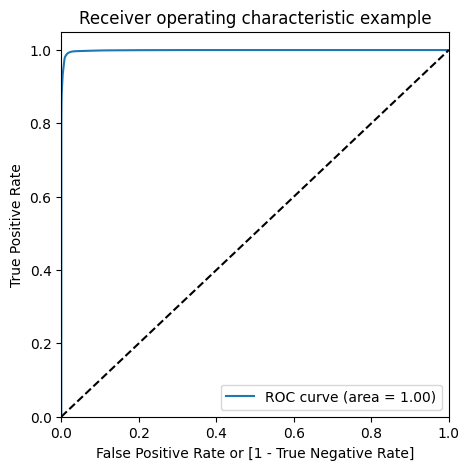

In [ ]:
# Predicted probability
y_train_pred_proba = dt_smote_model.predict_proba(X_train_smote)[:,1]
# Plot the ROC curve
draw_roc(y_train_smote, y_train_pred_proba)

### Evaluating the model on Test data

In [ ]:
# Evaluating model on the test data
y_pred = dt_smote_model.predict(X_test)
display_scores(y_test, y_pred)

F1 Score: 15.95%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.09      0.86      0.16        98

    accuracy                           0.98     56962
   macro avg       0.54      0.92      0.58     56962
weighted avg       1.00      0.98      0.99     56962



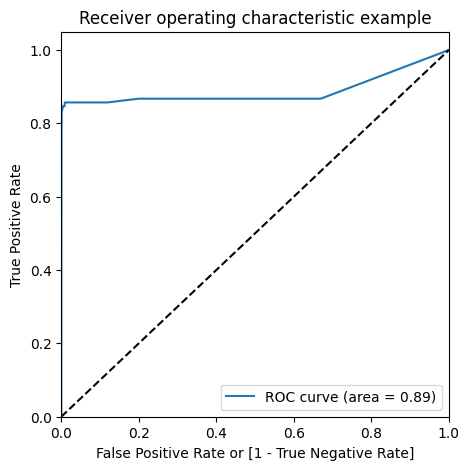

In [ ]:
# Predicted probability
y_test_pred_smote = dt_smote_model.predict_proba(X_test)[:,1]
# Plot the ROC curve
draw_roc(y_test, y_test_pred_smote)

__Observation on Decision tree with SMOTE__

- F1 score on train data 98%
- Best ROC score on train data 99%

- F1 score on test data 15.95%
- Best ROC score in test data 89%

### __3. XG Boost with SMOTE__

In [ ]:
# creating a KFold object 
folds = 3

# specify range of hyperparameters
param_grid = {'learning_rate': [0.2, 0.6], 
             'subsample': [0.3, 0.6, 0.9]}          


# specify model
xgb_model = XGBClassifier(max_depth=2, n_estimators=200)

# set up GridSearchCV()
xgb_smote_cv = GridSearchCV(estimator = xgb_model, 
                        param_grid = param_grid, 
                        scoring= 'roc_auc', 
                        cv = folds, 
                        verbose = 1,
                        return_train_score=True)      

# fit the model
xgb_smote_cv.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=2,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=200, n_jobs=None,
                                     num_parallel_tree=None, predictor=None,
                                     random_state=None, ...),
             param_grid={'learning_rate': [0.2, 0.6],
                         'subsample': [0.3, 0.6, 0.9]},
             return_train_score=True, scoring='roc_auc', verbose=1)

In [ ]:
# cv results
xgb_smote_cv_out = pd.DataFrame(xgb_smote_cv.cv_results_)
xgb_smote_cv_out

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,81.511075,2.078520,0.403868,0.191593,0.2,0.3,"{'learning_rate': 0.2, 'subsample': 0.3}",0.999631,0.999519,0.999592,0.999581,0.000046,5,0.999629,0.999660,0.999594,0.999628,0.000027
1,116.062807,0.594368,0.272340,0.007442,0.2,0.6,"{'learning_rate': 0.2, 'subsample': 0.6}",0.999626,0.999520,0.999622,0.999590,0.000049,4,0.999628,0.999654,0.999618,0.999633,0.000015
2,140.242756,0.704684,0.357083,0.090681,0.2,0.9,"{'learning_rate': 0.2, 'subsample': 0.9}",0.999601,0.999501,0.999576,0.999559,0.000042,6,0.999608,0.999650,0.999580,0.999612,0.000029
3,78.908280,0.687669,0.327826,0.085487,0.6,0.3,"{'learning_rate': 0.6, 'subsample': 0.3}",0.999961,0.999869,0.999928,0.999919,0.000038,3,0.999957,0.999961,0.999959,0.999959,0.000002
4,115.513186,0.883430,0.271590,0.003800,0.6,0.6,"{'learning_rate': 0.6, 'subsample': 0.6}",0.999959,0.999901,0.999931,0.999930,0.000023,2,0.999961,0.999969,0.999963,0.999964,0.000003
5,139.404481,0.782803,0.275192,0.007260,0.6,0.9,"{'learning_rate': 0.6, 'subsample': 0.9}",0.999965,0.999903,0.999940,0.999936,0.000025,1,0.999964,0.999973,0.999970,0.999969,0.000004


In [ ]:
# Printing the optimal score and hyperparameters
print("Best roc auc score : ", xgb_smote_cv.best_score_)
print(xgb_smote_cv.best_estimator_)

Best roc auc score :  0.999935806795636
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.6, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=200, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)


### XG Boost with optimal Hyperparameter

In [ ]:
xgb_smote_cv.best_params_

{'learning_rate': 0.6, 'subsample': 0.9}

In [ ]:
# chosen hyperparameters
# 'objective':'binary:logistic' outputs probability rather than label, which we need for calculating auc
params = {'learning_rate': 0.6,
          'max_depth': 2, 
          'n_estimators':200,
          'subsample':0.6,
         'objective':'binary:logistic'}

# fit model on training data
xgb_smote_model = XGBClassifier(params = params)
xgb_smote_model.fit(X_train_smote, y_train_smote)

[10:05:09] WARNING: ../src/learner.cc:767: 
Parameters: { "params" } are not used.



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              params={'learning_rate': 0.6, 'max_depth': 2, 'n_estimators': 200,
                      'objective': 'binary:logistic', 'subsample': 0.6},
              predictor=None, ...)

### Evaluating the model on train data

In [ ]:
y_train_pred = xgb_smote_model.predict(X_train_smote)
display_scores(y_train_smote, y_train_pred)

F1 Score: 100.0%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00    227451

    accuracy                           1.00    454902
   macro avg       1.00      1.00      1.00    454902
weighted avg       1.00      1.00      1.00    454902



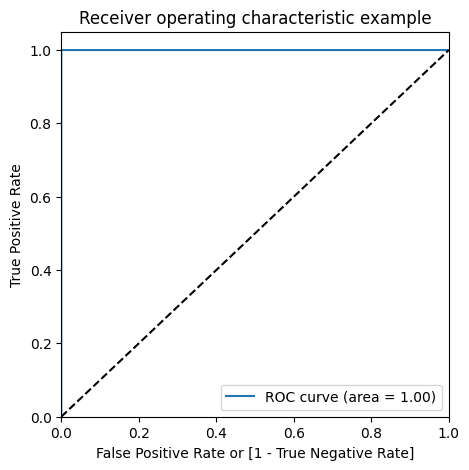

In [ ]:
# Predicted probability
y_train_pred_proba = xgb_smote_model.predict_proba(X_train_smote)[:,1]
# Plot the ROC curve
draw_roc(y_train_smote, y_train_pred_proba)

### Evaluating the model on test data

In [ ]:
y_pred = xgb_smote_model.predict(X_test)
display_scores(y_test, y_pred)

F1 Score: 78.18%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.70      0.88      0.78        98

    accuracy                           1.00     56962
   macro avg       0.85      0.94      0.89     56962
weighted avg       1.00      1.00      1.00     56962



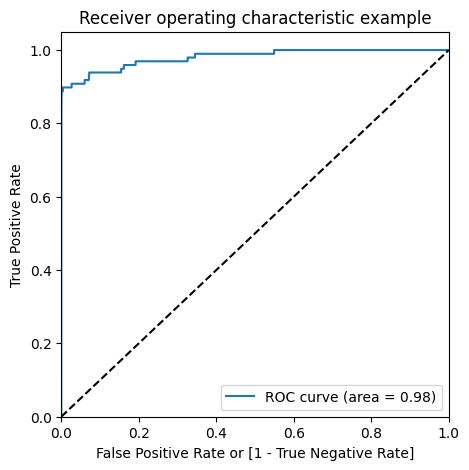

In [ ]:
# Predicted probability
y_test_pred_proba = xgb_smote_model.predict_proba(X_test)[:,1]
# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba)

__Observation on XG Boost with SMOTE__

- F1 score on train data 100%
- Best ROC score on train data 1
- F1 score on test data 78%
- ROC score on test data 98%

### __ADASYN__

### Print the class distribution after applying ADASYN

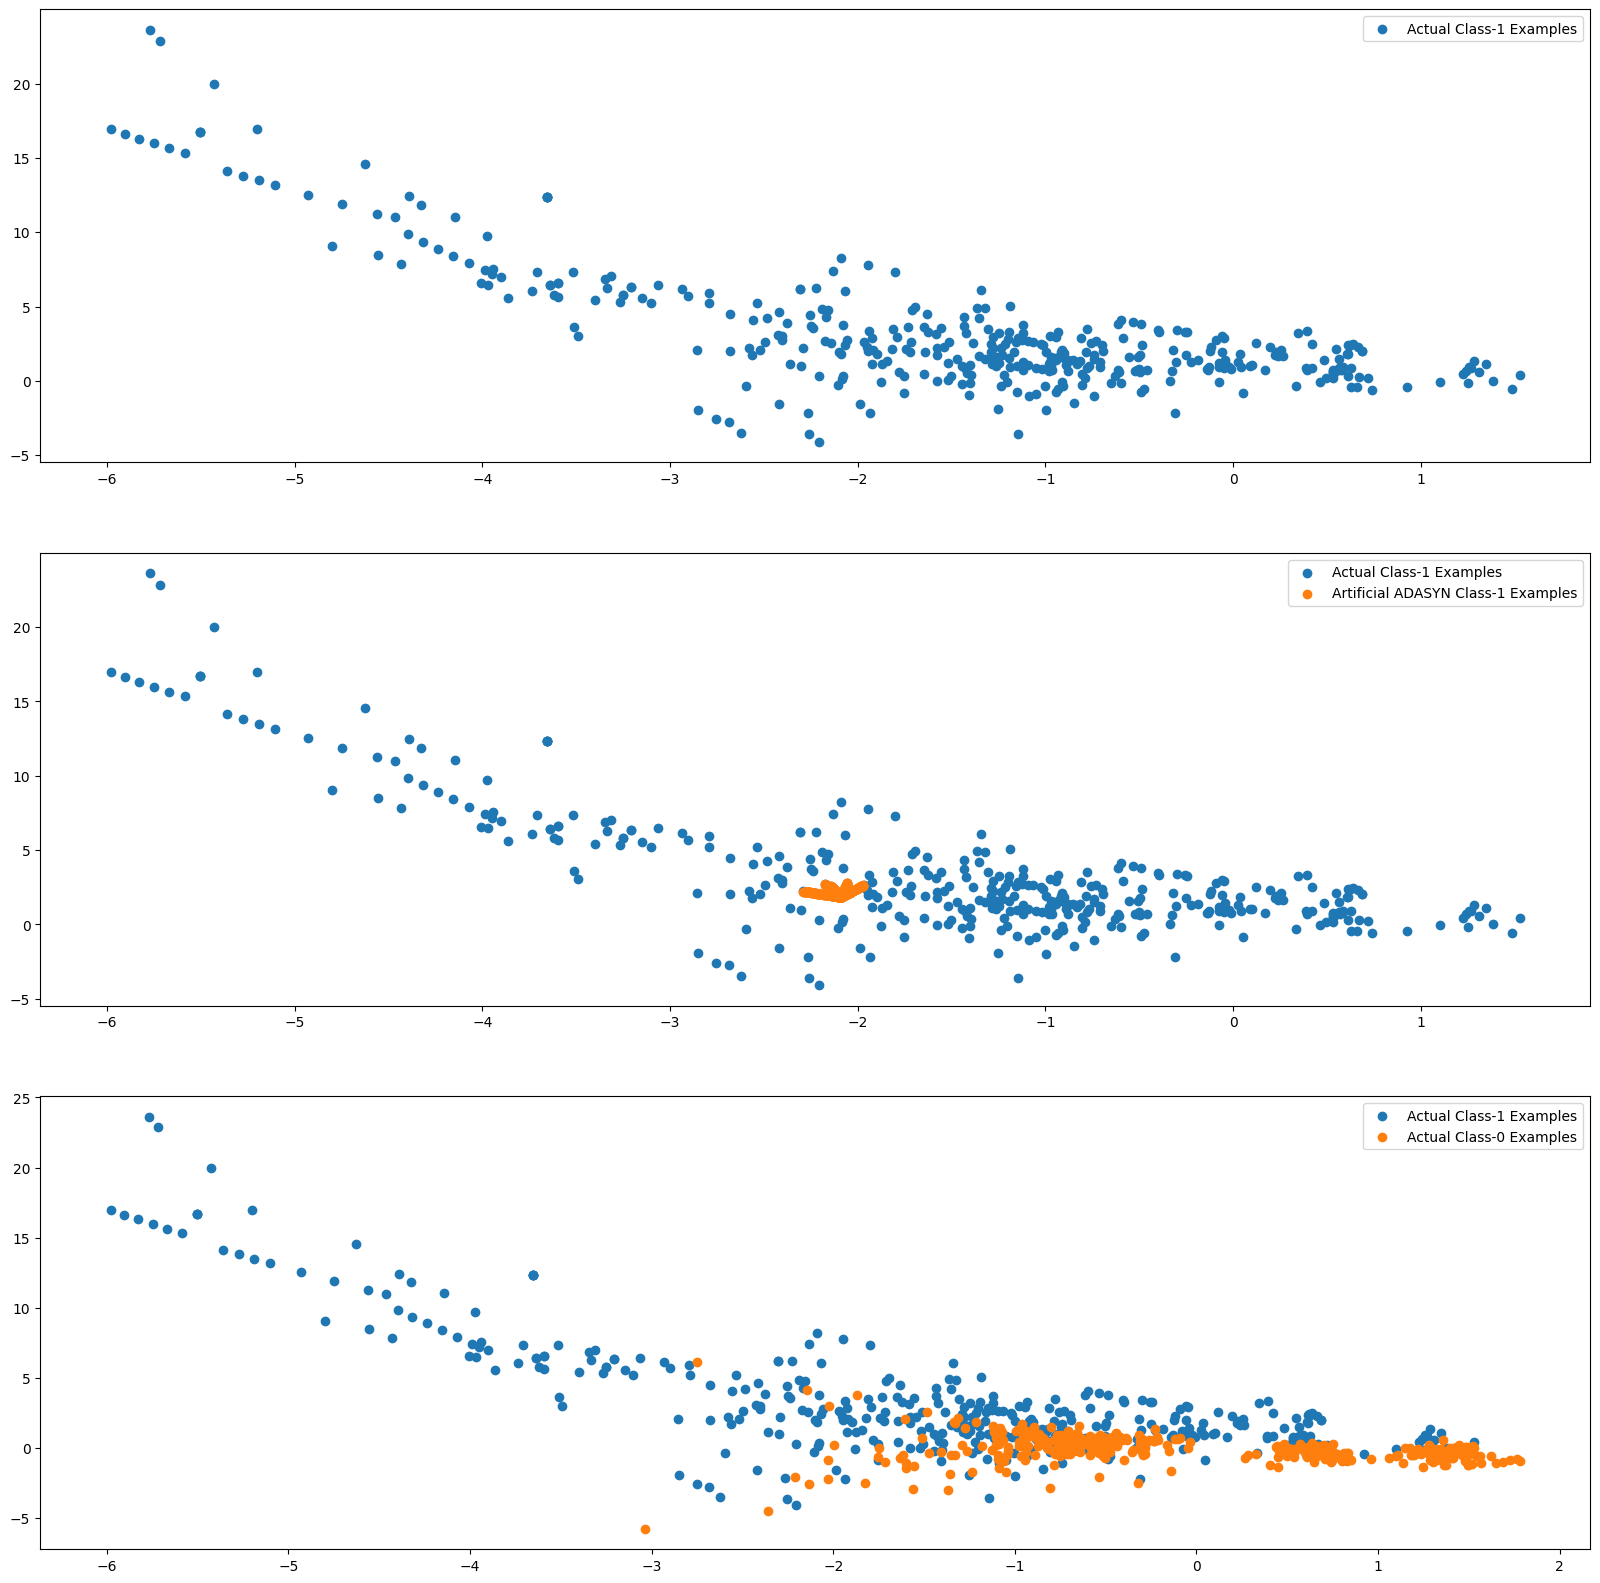

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from imblearn import over_sampling

ada = over_sampling.ADASYN(random_state=0)
X_train_adasyn, y_train_adasyn = ada.fit_resample(X_train, y_train)
# Artificial minority samples and corresponding minority labels from ADASYN are appended
# below X_train and y_train respectively
# So to exclusively get the artificial minority samples from ADASYN, we do
X_train_adasyn_1 = X_train_adasyn[X_train.shape[0]:]

X_train_1 = X_train.to_numpy()[np.where(y_train==1.0)]
X_train_0 = X_train.to_numpy()[np.where(y_train==0.0)]



import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 20]
fig = plt.figure()

plt.subplot(3, 1, 1)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.legend()

plt.subplot(3, 1, 2)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_train_adasyn_1.iloc[:X_train_1.shape[0], 0], X_train_adasyn_1.iloc[:X_train_1.shape[0], 1],
            label='Artificial ADASYN Class-1 Examples')
plt.legend()

plt.subplot(3, 1, 3)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_train_0[:X_train_1.shape[0], 0], X_train_0[:X_train_1.shape[0], 1], label='Actual Class-0 Examples')
plt.legend()

### Applying Logistice Regression with ADASYN

In [ ]:
# Creating KFold object with 3 splits
folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=4)

# Specify params
params = {"C": [0.01, 0.1, 1, 10, 100, 1000]}

# Specifing score as roc-auc
logreg_adasyn_cv = GridSearchCV(estimator = LogisticRegression(),
                        param_grid = params, 
                        scoring= 'roc_auc', 
                        cv = folds, 
                        verbose = 1,
                        return_train_score=True) 

# Fit the model
logreg_adasyn_cv.fit(X_train_adasyn, y_train_adasyn)
#print the evaluation result by choosing a evaluation metric
print('Best ROC AUC score: ', logreg_adasyn_cv.best_score_)
#print the optimum value of hyperparameters
print('Best hyperparameters: ', logreg_adasyn_cv.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best ROC AUC score:  0.9673022499470713
Best hyperparameters:  {'C': 100}


In [ ]:
# cross validation results
logreg_adasy_cv_out = pd.DataFrame(logreg_adasyn_cv.cv_results_)
logreg_adasy_cv_out

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,5.160830,0.604155,0.116566,0.017185,0.01,{'C': 0.01},0.967138,0.967853,0.966448,0.967146,0.000574,6,0.967129,0.966817,0.967569,0.967172,0.000309
1,4.989241,0.552881,0.103971,0.008792,0.1,{'C': 0.1},0.967260,0.967992,0.966617,0.967290,0.000562,5,0.967276,0.966957,0.967711,0.967315,0.000309
2,5.404534,0.478224,0.099158,0.008544,1,{'C': 1},0.967264,0.968004,0.966625,0.967298,0.000563,4,0.967281,0.966969,0.967717,0.967322,0.000307
3,5.208091,0.411531,0.102045,0.014541,10,{'C': 10},0.967267,0.968005,0.966630,0.967300,0.000562,3,0.967285,0.966970,0.967721,0.967325,0.000308
4,4.947275,0.301203,0.099353,0.004961,100,{'C': 100},0.967270,0.968005,0.966631,0.967302,0.000561,1,0.967289,0.966970,0.967722,0.967327,0.000308
5,5.186750,0.643337,0.124807,0.046262,1000,{'C': 1000},0.967271,0.968005,0.966629,0.967302,0.000562,2,0.967290,0.966970,0.967720,0.967327,0.000307


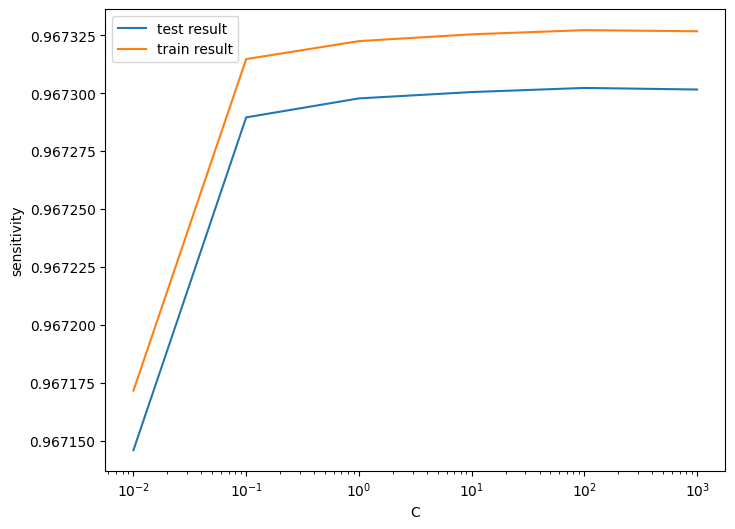

In [ ]:
# plot of C versus train and validation scores

plt.figure(figsize=(8, 6))
plt.plot(logreg_adasy_cv_out['param_C'], logreg_adasy_cv_out['mean_test_score'])
plt.plot(logreg_adasy_cv_out['param_C'], logreg_adasy_cv_out['mean_train_score'])
plt.xlabel('C')
plt.ylabel('sensitivity')
plt.legend(['test result', 'train result'], loc='upper left')
plt.xscale('log')

### Logistic Regression with Optimal C

In [ ]:
logreg_adasyn_cv.best_params_

{'C': 100}

In [ ]:
# Instantiating the model
logreg_adasyn_model = LogisticRegression(C=1000)

# Fitting the model 
logreg_adasyn_model.fit(X_train_adasyn, y_train_adasyn)

LogisticRegression(C=1000)

### Evaluating the model with tain data

In [ ]:
# Evaluating on test data
y_train_pred = logreg_adasyn_model.predict(X_train_adasyn)
display_scores(y_train_adasyn, y_train_pred)

F1 Score: 90.81%
Classification Report: 
               precision    recall  f1-score   support

           0       0.91      0.91      0.91    227451
           1       0.91      0.90      0.91    227461

    accuracy                           0.91    454912
   macro avg       0.91      0.91      0.91    454912
weighted avg       0.91      0.91      0.91    454912



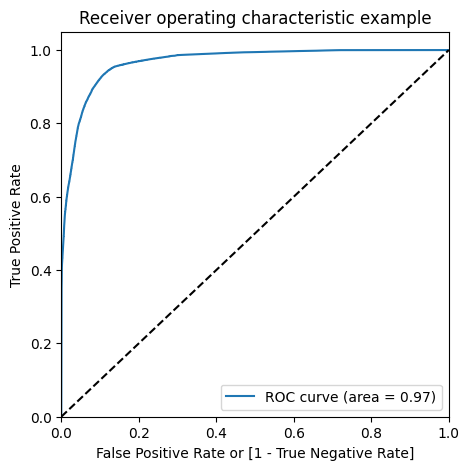

In [ ]:
# Predicted probability
y_train_pred_proba = logreg_adasyn_model.predict_proba(X_train_adasyn)[:,1]
# Plot the ROC curve
draw_roc(y_train_adasyn, y_train_pred_proba)

### Evaluating the model on test data

In [ ]:
# Evaluating on test data
y_pred = logreg_adasyn_model.predict(X_test)
display_scores(y_test, y_pred)

F1 Score: 3.39%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      0.91      0.95     56864
           1       0.02      0.92      0.03        98

    accuracy                           0.91     56962
   macro avg       0.51      0.91      0.49     56962
weighted avg       1.00      0.91      0.95     56962



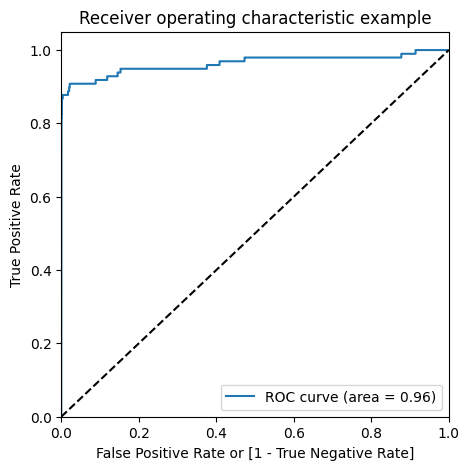

In [ ]:
# Predicted probability
y_test_pred_proba = logreg_adasyn_model.predict_proba(X_test)[:,1]
# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba)

__Observation on Logistic Regression with ADASYN__

- F1 score on train data 90%
- Best ROC on train data 97%
- F1 score on test data 3.39%
- Best ROC on test data 96%

### __2. Decision tree with ADASYN__

In [ ]:
# Create the parameter grid 
param_grid = {
    'max_depth': range(5, 15, 5),
    'min_samples_leaf': range(50, 150, 50),
    'min_samples_split': range(50, 150, 50),
}


# Instantiate the grid search model
dtree = DecisionTreeClassifier()

grid_search = GridSearchCV(estimator = dtree, 
                           param_grid = param_grid, 
                           scoring= 'roc_auc',
                           cv = 5, 
                           n_jobs=-1,
                           verbose = 1)

# Fit the grid search to the data
grid_search.fit(X_train_adasyn,y_train_adasyn)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'max_depth': range(5, 15, 5),
                         'min_samples_leaf': range(50, 150, 50),
                         'min_samples_split': range(50, 150, 50)},
             scoring='roc_auc', verbose=1)

In [ ]:
# Printing the optimal roc score and hyperparameters
print("Best roc auc score : ", grid_search.best_score_)
print(grid_search.best_estimator_)

Best roc auc score :  0.9384118041443129
DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, min_samples_split=50)


### Model with Optimal Hyperparameters

In [ ]:
# Model with optimal hyperparameters
dt_adasyn_model = DecisionTreeClassifier(criterion = "gini", 
                                  random_state = 100,
                                  max_depth=10, 
                                  min_samples_leaf=50,
                                  min_samples_split=100)

dt_adasyn_model.fit(X_train_adasyn, y_train_adasyn)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, min_samples_split=100,
                       random_state=100)

### Evaluating the model on train data

In [ ]:
# Evaluating model on the test data
y_train_pred = dt_adasyn_model.predict(X_train_adasyn)
display_scores(y_train_adasyn, y_train_pred)

F1 Score: 97.94%
Classification Report: 
               precision    recall  f1-score   support

           0       0.99      0.97      0.98    227451
           1       0.97      0.99      0.98    227461

    accuracy                           0.98    454912
   macro avg       0.98      0.98      0.98    454912
weighted avg       0.98      0.98      0.98    454912



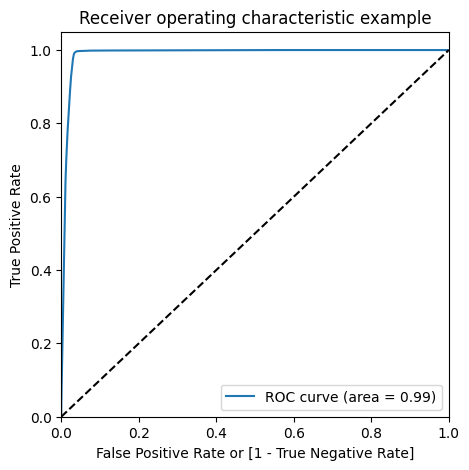

In [ ]:
# Predicted probability
y_train_pred_proba = dt_adasyn_model.predict_proba(X_train_adasyn)[:,1]
# Plot the ROC curve
draw_roc(y_train_adasyn, y_train_pred_proba)

### Evaluating the model on test data

In [ ]:
# Evaluating model on the test data
y_pred = dt_adasyn_model.predict(X_test)
display_scores(y_test, y_pred)

F1 Score: 7.91%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.04      0.88      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.92      0.53     56962
weighted avg       1.00      0.96      0.98     56962



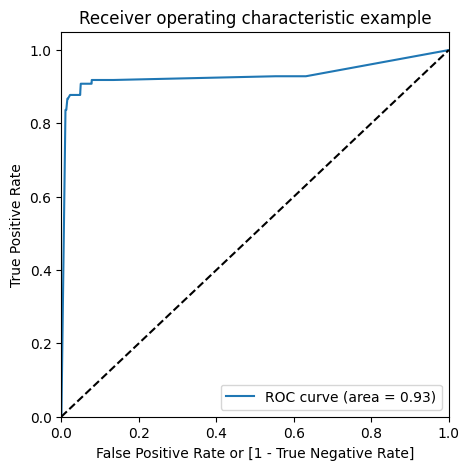

In [ ]:
# Predicted probability
y_test_pred_proba = dt_adasyn_model.predict_proba(X_test)[:,1]
# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba)

### __3. XG Boost on ADASYN__

In [ ]:
# creating a KFold object 
folds = 3

# specify range of hyperparameters
param_grid = {'learning_rate': [0.2, 0.6], 
             'subsample': [0.3, 0.6, 0.9]}          


# specify model
xgb_model_adasyn = XGBClassifier(max_depth=2, n_estimators=200)

# set up GridSearchCV()
xgb_adasyn_cv = GridSearchCV(estimator = xgb_model_adasyn, 
                        param_grid = param_grid, 
                        scoring= 'roc_auc', 
                        cv = folds, 
                        verbose = 1,
                        return_train_score=True)      

# fit the model
xgb_adasyn_cv.fit(X_train_adasyn, y_train_adasyn)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=2,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=200, n_jobs=None,
                                     num_parallel_tree=None, predictor=None,
                                     random_state=None, ...),
             param_grid={'learning_rate': [0.2, 0.6],
                         'subsample': [0.3, 0.6, 0.9]},
             return_train_score=True, scoring='roc_auc', verbose=1)

In [ ]:
# cv results
xgb_adasyn_cv_out = pd.DataFrame(xgb_adasyn_cv.cv_results_)
xgb_adasyn_cv_out

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,79.495035,1.425018,0.272987,0.000878,0.2,0.3,"{'learning_rate': 0.2, 'subsample': 0.3}",0.994256,0.991128,0.990816,0.992066,0.001553,4,0.999116,0.999201,0.998970,0.999096,0.000095
1,117.039735,1.139359,0.349171,0.112812,0.2,0.6,"{'learning_rate': 0.2, 'subsample': 0.6}",0.992648,0.988922,0.991644,0.991071,0.001574,6,0.999037,0.999011,0.998914,0.998987,0.000053
2,140.266047,1.501973,0.267860,0.001292,0.2,0.9,"{'learning_rate': 0.2, 'subsample': 0.9}",0.994176,0.990186,0.990020,0.991461,0.001921,5,0.999087,0.999035,0.999059,0.999060,0.000021
3,78.647284,0.719047,0.272923,0.009161,0.6,0.3,"{'learning_rate': 0.6, 'subsample': 0.3}",0.998551,0.986914,0.995896,0.993787,0.004979,3,0.999915,0.999938,0.999888,0.999914,0.000020
4,116.558567,0.857197,0.272244,0.003919,0.6,0.6,"{'learning_rate': 0.6, 'subsample': 0.6}",0.997304,0.990912,0.995355,0.994524,0.002675,2,0.999929,0.999937,0.999919,0.999928,0.000008
5,140.800969,0.738039,0.364491,0.130661,0.6,0.9,"{'learning_rate': 0.6, 'subsample': 0.9}",0.997425,0.993680,0.994515,0.995207,0.001605,1,0.999944,0.999938,0.999930,0.999937,0.000006


In [ ]:
# Printing the optimal score and hyperparameters
print("Best roc auc score : ", xgb_adasyn_cv.best_score_)
print(xgb_adasyn_cv.best_estimator_)

Best roc auc score :  0.9952066951663888
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.6, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=200, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)


### XG Boost with Optimal Hyperparameter

In [ ]:
xgb_adasyn_cv.best_params_

{'learning_rate': 0.6, 'subsample': 0.9}

In [ ]:
# chosen hyperparameters
# 'objective':'binary:logistic' outputs probability rather than label, which we need for calculating auc
params = {'learning_rate': 0.6,
          'max_depth': 2, 
          'n_estimators':200,
          'subsample':0.9,
          'objective':'binary:logistic'}

# Model with optimal hyperparameter
xgb_adasyn_model = XGBClassifier(params = params)
xgb_adasyn_model.fit(X_train_adasyn,y_train_adasyn)

[11:46:19] WARNING: ../src/learner.cc:767: 
Parameters: { "params" } are not used.



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              params={'learning_rate': 0.6, 'max_depth': 2, 'n_estimators': 200,
                      'objective': 'binary:logistic', 'subsample': 0.9},
              predictor=None, ...)

### Evaluating the model on train data

In [ ]:
# Predicting on the train set
y_train_pred = xgb_adasyn_model.predict(X_train_adasyn)
# Printing the scores
display_scores(y_train_adasyn, y_train_pred)

F1 Score: 100.0%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00    227461

    accuracy                           1.00    454912
   macro avg       1.00      1.00      1.00    454912
weighted avg       1.00      1.00      1.00    454912



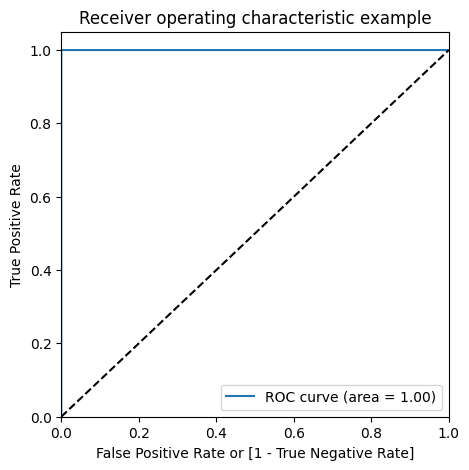

In [ ]:
# Predicted probability
y_train_pred_proba = xgb_adasyn_model.predict_proba(X_train_adasyn)[:,1]
# Plot the ROC curve
draw_roc(y_train_adasyn, y_train_pred_proba)

### Evaluatig the model on test data

In [ ]:
y_pred = xgb_adasyn_model.predict(X_test)
display_scores(y_test, y_pred)

F1 Score: 78.7%
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.87      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



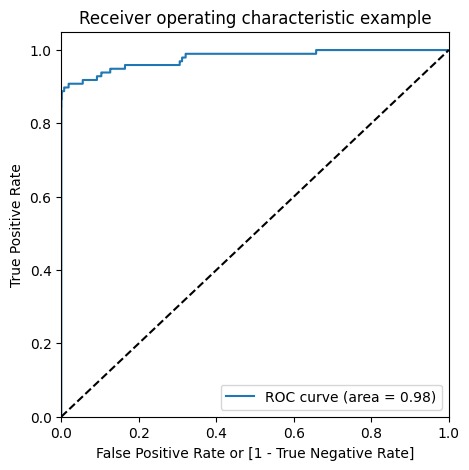

In [ ]:
# Predicted probability
y_test_pred_proba = xgb_adasyn_model.predict_proba(X_test)[:,1]
# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba)

__Observation on XG Boost with ADASYN__

 - F1 score on train data 100
 - Best ROC score on train data 1
 - F1 score on test data  78%
 - Best ROC score on test data 98%

### Select the oversampling method which shows the best result on a model

Applying several techniques to solve class imbalance, such as, Random Oversampling, SMOTE and ADASYN then building machine learning models such as Logistic Regression, Decision Tree and XGBoost, we have found out the differece on the model that is performing the best.

- __XG Boost model is performing best__ on data after applying __ADASYN sampling technique__ with ROC of 98% on test data.

### Print the important features of the best model to understand the dataset

Top var = 14
2nd Top var = 4
3rd Top var = 8


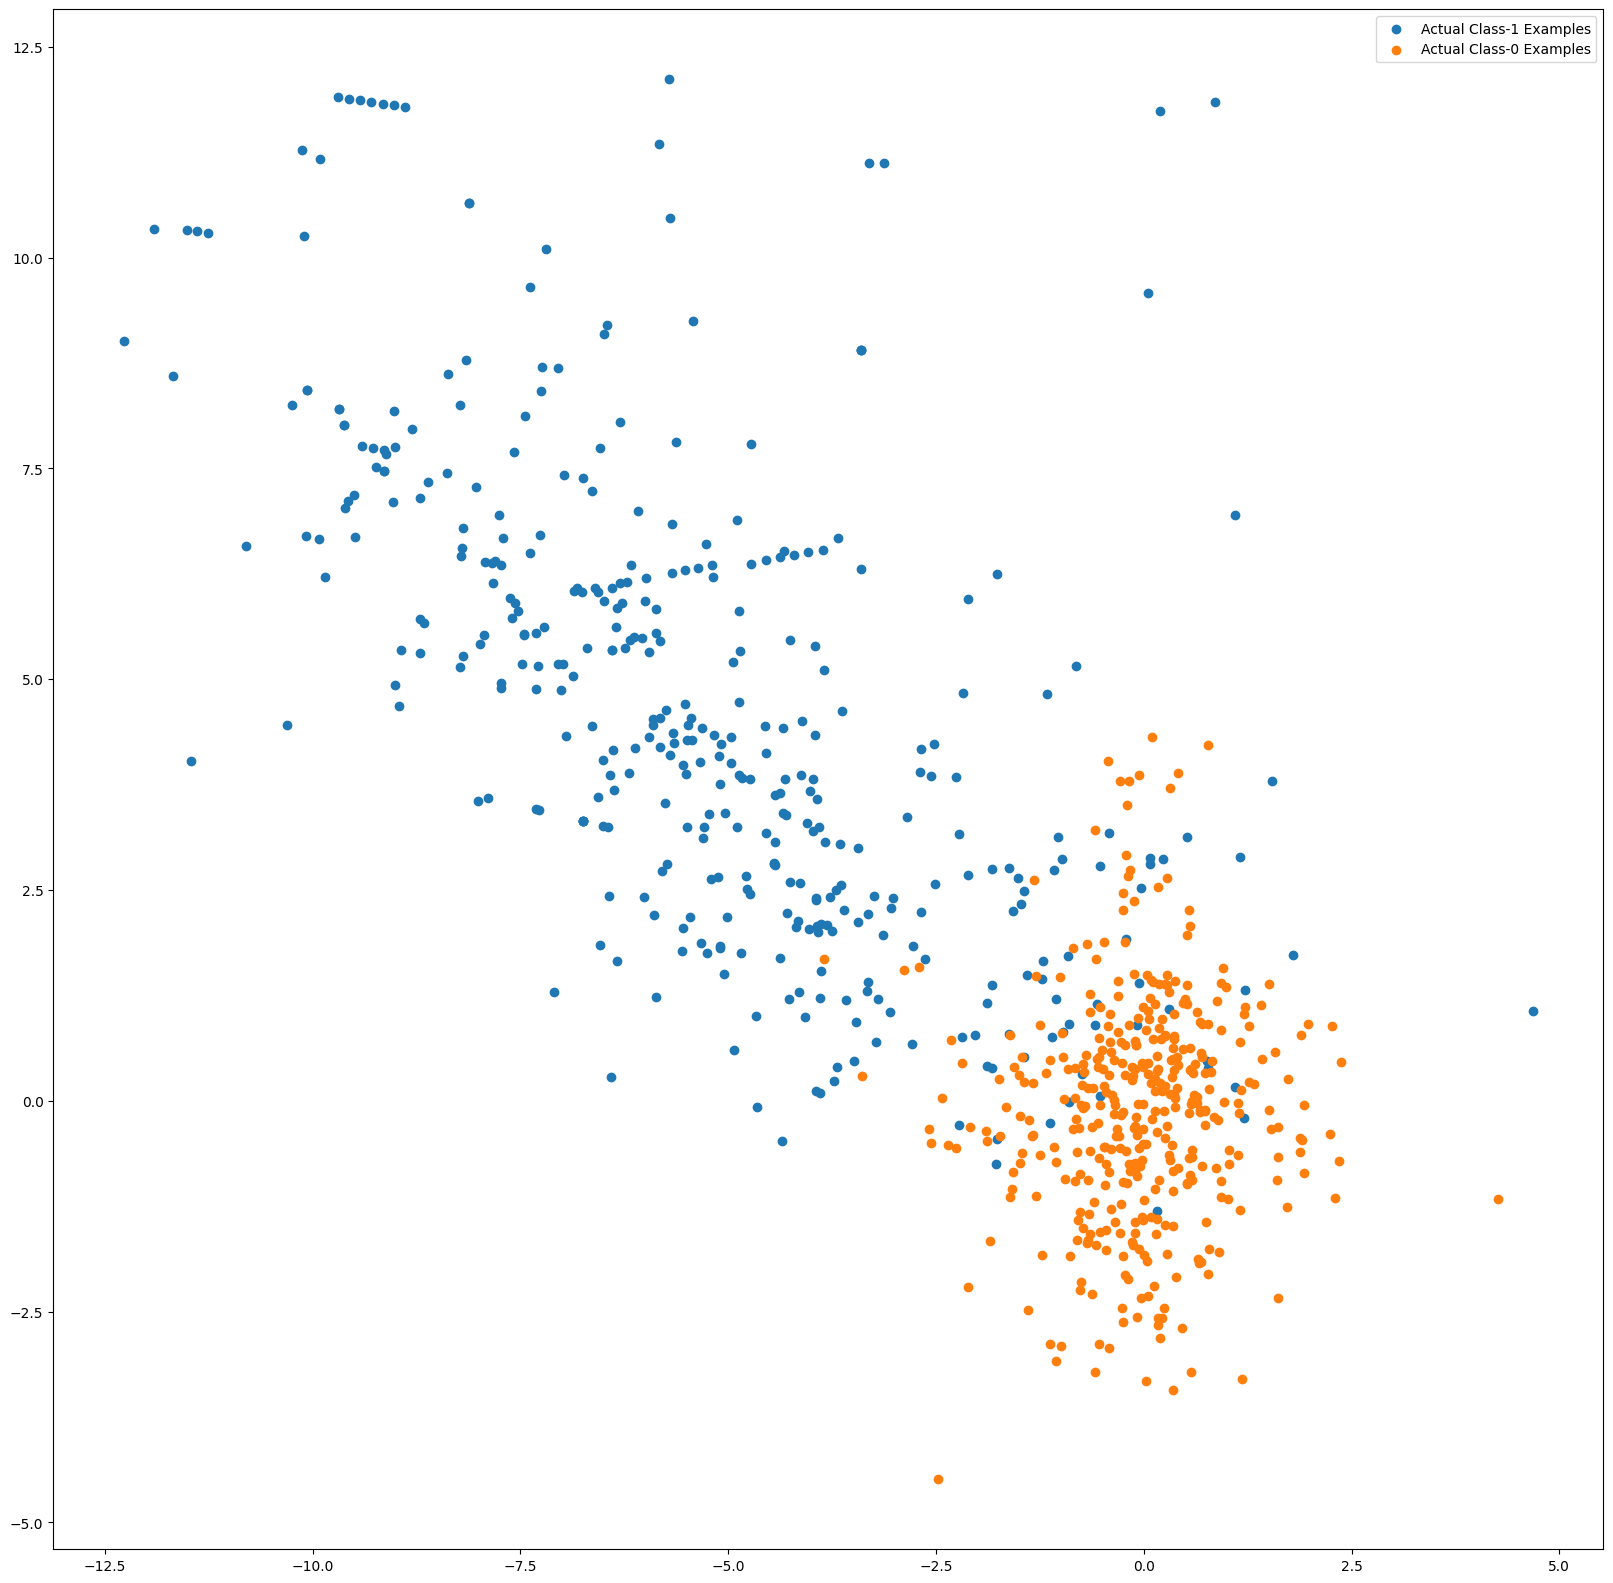

In [ ]:
var_imp = []
for i in xgb_adasyn_model.feature_importances_:
    var_imp.append(i)
print('Top var =', var_imp.index(np.sort(xgb_adasyn_model.feature_importances_)[-1])+1)
print('2nd Top var =', var_imp.index(np.sort(xgb_adasyn_model.feature_importances_)[-2])+1)
print('3rd Top var =', var_imp.index(np.sort(xgb_adasyn_model.feature_importances_)[-3])+1)

# Variable on Index-13 and Index-9 seems to be the top 2 variables
top_var_index = var_imp.index(np.sort(xgb_adasyn_model.feature_importances_)[-1])
second_top_var_index = var_imp.index(np.sort(xgb_adasyn_model.feature_importances_)[-2])

X_train_1 = X_train.to_numpy()[np.where(y_train==1.0)]
X_train_0 = X_train.to_numpy()[np.where(y_train==0.0)]

np.random.shuffle(X_train_0)

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 20]

plt.scatter(X_train_1[:, top_var_index], X_train_1[:, second_top_var_index], label='Actual Class-1 Examples')
plt.scatter(X_train_0[:X_train_1.shape[0], top_var_index], X_train_0[:X_train_1.shape[0], second_top_var_index],
            label='Actual Class-0 Examples')
plt.legend()

#### Print the FPR,TPR & select the best threshold from the roc curve

In [ ]:
print('Train auc =', metrics.roc_auc_score(y_train_adasyn, y_train_pred_proba))
fpr, tpr, thresholds = metrics.roc_curve(y_train_adasyn, y_train_pred_proba )
threshold = thresholds[np.argmax(tpr-fpr)]
print(threshold)

Train auc = 1.0
0.90155745


  Threshold of 90% for which TPR is the highest and FPR is the lowest and train ROC of 1.

## __8. Conclusion__

- We finally conclude that the balanced dataset with __ADASYN technique applying XG Boost model is best__ has a good ROC score of 98% in test data and recall of 90%